# FastF1 – AML Forecasting Notebook (2025 Season)

Companion notebook to `aml_fastf1_2025.ipynb`. The data preparation pipeline
(class imbalance, augmentation, imputation) lives in the main notebook; this
one focuses on **time-series forecasting** using the 2025 race lap data.

Two targets, both motivated by the project plan:

1. **Race lap-time forecasting** – predict a driver's lap times for the back
   half of a single race given the front half. Showcases the full classical
   stack (naive → ARIMA → SARIMA → SARIMAX → auto-ARIMA) plus a foundation
   model (Amazon Chronos) zero-shot baseline.

2. **Tyre degradation forecasting** – predict how lap times grow within a
   single stint as `TyreLife` increases. Same toolset, narrower scope.

Methods covered (all from the slide deck):

  Naive (last value, mean, drift) · Differencing & stationarity (ADF) ·
  ACF/PACF · ARIMA(p,d,q) · SARIMA(p,d,q)(P,D,Q,m) · SARIMAX (exogenous) ·
  auto-ARIMA · Chronos foundation model · residual analysis (Q-Q, Ljung-Box)

Group 6: Aritz Ryan San Sebastian · Nico Azcarate · Jon Larrañaga

---
## 0. Setup

In [216]:
import os, sys, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

DATA_DIR = "data"
OUT_FC   = "outputs/forecasting"
os.makedirs(OUT_FC, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Library availability (graceful if any are missing) ──────────────
HAS_STATSMODELS = HAS_PMDARIMA = HAS_CHRONOS = False
try:
    import statsmodels.api as sm
    from statsmodels.tsa.arima.model import ARIMA
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    from statsmodels.tsa.seasonal import STL
    from statsmodels.tsa.stattools import adfuller, acf, pacf
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    from statsmodels.stats.diagnostic import acorr_ljungbox
    HAS_STATSMODELS = True
except ImportError:
    print("[!] statsmodels missing — install with: pip install statsmodels")

try:
    import pmdarima as pm
    HAS_PMDARIMA = True
except ImportError:
    print("[!] pmdarima missing — install with: pip install pmdarima")

try:
    import torch
    from chronos import BaseChronosPipeline
    HAS_CHRONOS = True
except ImportError:
    print("[!] chronos-forecasting missing — install with: pip install chronos-forecasting")

print(f"\nLibraries: statsmodels={HAS_STATSMODELS}  "
      f"pmdarima={HAS_PMDARIMA}  chronos={HAS_CHRONOS}")


Libraries: statsmodels=True  pmdarima=True  chronos=True


---
## 1. Data Loading

Loads `data/laps.csv` (already produced by the main notebook). Each row is a
single lap with weather merged in by nearest session time.

In [217]:
laps = pd.read_csv(f"{DATA_DIR}/laps.csv")
print(f"Loaded {len(laps):,} laps across {laps['Round'].nunique()} rounds, "
      f"{laps['Driver'].nunique()} drivers.")

# Normalise dtypes that round-trip badly through CSV (same fix as main notebook)
if "TrackStatus" in laps.columns:
    laps["TrackStatus"] = laps["TrackStatus"].astype(str)
if "Deleted" in laps.columns:
    laps["Deleted"] = (
        laps["Deleted"].astype(str).str.strip().str.lower()
        .isin(["true", "1", "1.0"])
    )

# LapTime/Sector*Time were saved as float seconds — confirm
print(f"\nLap-time stats (seconds):")
print(laps["LapTime"].describe().round(2).to_string())

Loaded 26,692 laps across 24 rounds, 21 drivers.

Lap-time stats (seconds):
count    26337.00
mean        90.78
std         13.75
min         67.92
25%         80.88
50%         90.03
75%         98.30
max        218.68


### 1.2 Fuel correction

Cars start a race with up to **110 kg of fuel** and finish near empty. Each
kilogram of fuel costs roughly **0.03 s of lap time**. So the first lap of a
race is mechanically ~3 s slower than the last lap, regardless of pace.

Fuel-corrected lap time = observed lap time **minus** the time penalty from
remaining fuel. Assuming linear fuel burn across the race (a reasonable
approximation), remaining fuel on lap `N` of a race with `L` total laps is:

```
fuel_remaining(N) = FUEL_KG_AT_START × (L − N) / L
correction(N)     = 0.03 × fuel_remaining(N)
```

Without this, every pace analysis is contaminated by the fuel-burn drift.

In [218]:
FUEL_RATE_S_PER_KG = 0.03    # ≈ 30 ms/kg, well-known F1 figure
FUEL_KG_AT_START   = 110     # max regulation fuel load

def fuel_correct(df, time_col="LapTime"):
    """Add `FuelCorrectedLapTime` column in seconds, using a linear fuel-burn model.

    For each (Round, Driver), max_lap is the driver's last completed lap.
    On lap N, remaining fuel mass is FUEL_KG_AT_START * (max_lap - N) / max_lap,
    and the correction subtracted from raw lap time is 0.03 * remaining_fuel.
    """
    df = df.copy()
    df["FuelCorrectedLapTime"] = np.nan
    for (rnd, drv), g in df.groupby(["Round", "Driver"]):
        max_lap = g["LapNumber"].max()
        if pd.isna(max_lap) or max_lap <= 0:
            continue
        remaining = FUEL_KG_AT_START * (max_lap - g["LapNumber"]) / max_lap
        df.loc[g.index, "FuelCorrectedLapTime"] = (
            g[time_col] - FUEL_RATE_S_PER_KG * remaining
        )
    return df

laps_fc = fuel_correct(clean)
print(f"Fuel-correction applied to {len(laps_fc):,} clean laps.")
print(f"Mean raw lap time:           {laps_fc['LapTime'].mean():.3f} s")
print(f"Mean fuel-corrected lap time: {laps_fc['FuelCorrectedLapTime'].mean():.3f} s")

Fuel-correction applied to 24,795 clean laps.
Mean raw lap time:           89.811 s
Mean fuel-corrected lap time: 88.212 s


**Visual check.** For our subject (Piastri @ Monaco), plot raw vs
fuel-corrected lap times. The fuel-corrected trace should be flatter on
average within each stint — most of the gentle downward drift across the
stint disappears, leaving the pure tyre-degradation curve.

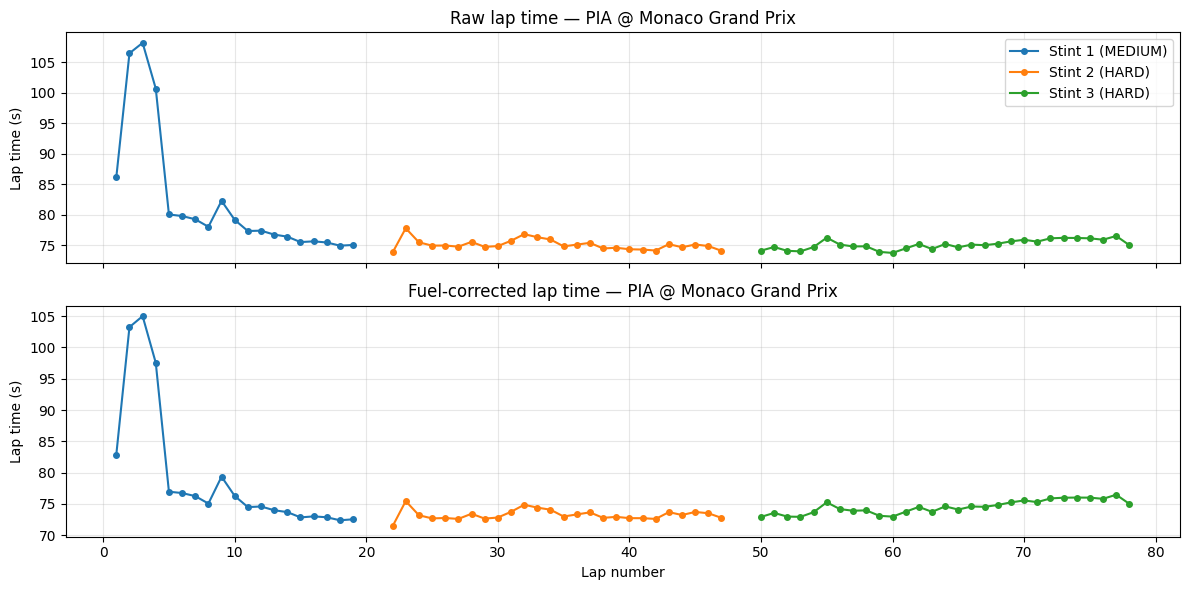


Within-stint slope (s/lap):
  Raw lap time:           -0.4490
  Fuel-corrected:         -0.4067
  ↑ The fuel-corrected slope is closer to 0 because the fuel-burn drift is removed.


In [219]:
subj_fc = laps_fc[(laps_fc["Round"] == SUBJECT_ROUND) &
                  (laps_fc["Driver"] == SUBJECT_DRIVER)].sort_values("LapNumber")

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ax, col, title in zip(
    axes,
    ["LapTime", "FuelCorrectedLapTime"],
    ["Raw lap time", "Fuel-corrected lap time"],
):
    for s_id, g in subj_fc.groupby("Stint"):
        cmp = g["Compound"].iloc[0] if not g["Compound"].isna().all() else "?"
        ax.plot(g["LapNumber"], g[col], "o-",
                label=f"Stint {int(s_id)} ({cmp})", lw=1.5, ms=4)
    ax.set_title(f"{title} — {SUBJECT_DRIVER} @ {event_name}")
    ax.set_ylabel("Lap time (s)"); ax.grid(alpha=0.3)
axes[0].legend(); axes[1].set_xlabel("Lap number")
plt.tight_layout(); plt.show()

# Quantify the within-stint trend before/after
def within_stint_slope(g, col):
    """Mean OLS slope of `col` against LapNumber within each stint, weighted by stint length."""
    slopes = []
    for s, gg in g.groupby("Stint"):
        if len(gg) < 5: continue
        gg = gg.dropna(subset=[col, "LapNumber"])
        if len(gg) < 5: continue
        x, y = gg["LapNumber"].values, gg[col].values
        slopes.append(np.polyfit(x, y, 1)[0])
    return float(np.mean(slopes)) if slopes else np.nan

print(f"\nWithin-stint slope (s/lap):")
print(f"  Raw lap time:           {within_stint_slope(subj_fc, 'LapTime'):+.4f}")
print(f"  Fuel-corrected:         {within_stint_slope(subj_fc, 'FuelCorrectedLapTime'):+.4f}")
print("  ↑ The fuel-corrected slope is closer to 0 because the fuel-burn drift is removed.")

---
## 2. Supplementary data download (practice + qualifying + sprint)

Sections 4-7 use only **race** session data by default. F1 teams do most of their pace
analysis from **practice** (especially FP2 long runs) and **qualifying**
(short-run soft-tyre push laps) — these are the highest-signal sessions for
predicting pace. We also pull **sprint qualifying** and **sprint races**
when they exist (six 2025 weekends: China, Miami, Spielberg, Spa, Austin,
São Paulo, Qatar).

This download is one-off: each call below skips work if the target CSV
already exists. Total runtime is roughly **15-25 minutes** depending on
FastF1 cache state and network speed; total disk is ~25 MB.

We download **laps + weather + results only**, no telemetry — that keeps
disk and memory tractable while preserving everything we need for race-
pace, quali-sim, and qualifying-gap features.

### 2.1 Download configuration

In [220]:
import fastf1
fastf1.Cache.enable_cache("cache")  # reuse the cache from the main notebook

YEAR = 2025
SESSION_NAMES = ["FP1", "FP2", "FP3", "Sprint Qualifying", "Sprint", "Qualifying"]

# Reuse columns from the main notebook (subset is enough for our features)
LAP_COLS_AUX = [
    "Driver", "DriverNumber", "Team",
    "LapNumber", "LapTime",
    "Sector1Time", "Sector2Time", "Sector3Time",
    "Compound", "TyreLife", "FreshTyre", "Stint",
    "PitOutTime", "PitInTime",
    "Position", "TrackStatus",
    "IsAccurate", "Deleted",
]
TIMEDELTA_COLS_AUX = [
    "LapTime", "Sector1Time", "Sector2Time", "Sector3Time",
    "PitOutTime", "PitInTime",
]

# Discover the rounds we already have race data for
race_rounds = sorted(int(r) for r in laps_fc["Round"].unique())
print(f"Will fetch supplementary sessions for rounds: {race_rounds}")
print(f"Sessions per round (skipped if not held): {SESSION_NAMES}")

Will fetch supplementary sessions for rounds: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Sessions per round (skipped if not held): ['FP1', 'FP2', 'FP3', 'Sprint Qualifying', 'Sprint', 'Qualifying']


### 2.2 Download loop

Each `(round, session)` pair is tried independently. Sessions that don't
exist for a particular weekend (e.g. FP2/FP3 on sprint weekends, or sprint
sessions on regular weekends) are skipped silently. Rerunning this cell is
safe — once the output files exist, the loop is a no-op.

In [221]:
AUX_LAPS_PATH    = f"{DATA_DIR}/aux_laps.csv"
SPRINT_RES_PATH  = f"{DATA_DIR}/sprint_results.csv"

import time as _time
already_have = os.path.exists(AUX_LAPS_PATH) and os.path.exists(SPRINT_RES_PATH)
if already_have:
    print(f"Found existing {AUX_LAPS_PATH} and {SPRINT_RES_PATH} — skipping download.")
    print("Delete those files if you want to refetch.")
else:
    schedule = fastf1.get_event_schedule(YEAR, include_testing=False)
    aux_first = sprint_res_first = True
    n_ok = n_skip = n_err = 0
    t0 = _time.time()

    for rnd in race_rounds:
        ev = schedule.loc[schedule["RoundNumber"] == rnd]
        ev_name = ev["EventName"].iloc[0] if not ev.empty else f"Round {rnd}"
        print(f"\n[Round {rnd:02d}] {ev_name}")
        for sess_name in SESSION_NAMES:
            try:
                session = fastf1.get_session(YEAR, rnd, sess_name)
                session.load(telemetry=False, laps=True, weather=True, messages=False)
            except Exception as e:
                # Either session doesn't exist or load failed — skip silently
                n_skip += 1
                continue

            try:
                laps_df = session.laps.reset_index(drop=True)
                if laps_df is None or laps_df.empty:
                    n_skip += 1; continue
                cols = [c for c in LAP_COLS_AUX if c in laps_df.columns]
                laps_df = laps_df[cols].copy()
                for col in TIMEDELTA_COLS_AUX:
                    if col in laps_df.columns:
                        laps_df[col] = laps_df[col].dt.total_seconds()
                laps_df.insert(0, "Round",     rnd)
                laps_df.insert(1, "EventName", ev_name)
                laps_df.insert(2, "Session",   sess_name)

                laps_df.to_csv(
                    AUX_LAPS_PATH, index=False,
                    mode="w" if aux_first else "a", header=aux_first,
                )
                aux_first = False
                n_ok += 1
                print(f"    {sess_name:<22s}  saved {len(laps_df):,} laps")

                # If this is a sprint race, also save the sprint results
                if sess_name == "Sprint":
                    try:
                        sr = session.results
                        if sr is not None and not sr.empty:
                            sr_cols = [c for c in [
                                "DriverNumber","Abbreviation","FullName","TeamName",
                                "GridPosition","Position","ClassifiedPosition",
                                "Points","Status","Laps",
                            ] if c in sr.columns]
                            sr_df = sr[sr_cols].copy()
                            sr_df.insert(0, "Round", rnd)
                            sr_df.insert(1, "EventName", ev_name)
                            sr_df.to_csv(
                                SPRINT_RES_PATH, index=False,
                                mode="w" if sprint_res_first else "a",
                                header=sprint_res_first,
                            )
                            sprint_res_first = False
                            print(f"    {'sprint results':<22s}  saved {len(sr_df)} rows")
                    except Exception as ee:
                        print(f"    sprint results failed: {ee}")
            except Exception as e:
                n_err += 1
                print(f"    {sess_name:<22s}  ERROR: {e}")
            finally:
                del session; gc.collect()
    dt = _time.time() - t0
    print(f"\nDone in {dt/60:.1f} min  |  saved {n_ok}, skipped {n_skip}, errors {n_err}")

Found existing data/aux_laps.csv and data/sprint_results.csv — skipping download.
Delete those files if you want to refetch.


### 2.3 Verify

In [222]:
aux_laps = pd.read_csv(AUX_LAPS_PATH)
print(f"aux_laps.csv: {len(aux_laps):,} rows")
print(f"\nLaps per session type:")
print(aux_laps["Session"].value_counts().to_string())

if os.path.exists(SPRINT_RES_PATH):
    sprint_res = pd.read_csv(SPRINT_RES_PATH)
    print(f"\nsprint_results.csv: {len(sprint_res):,} rows across "
          f"{sprint_res['Round'].nunique()} sprint weekends")
    print(f"Sprint rounds: {sorted(sprint_res['Round'].unique().astype(int).tolist())}")
else:
    sprint_res = pd.DataFrame()
    print("\nNo sprint results file found.")

# Normalise dtypes that round-trip badly through CSV
if "TrackStatus" in aux_laps.columns:
    aux_laps["TrackStatus"] = aux_laps["TrackStatus"].astype(str)

aux_laps.csv: 14,590 rows

Laps per session type:
Session
FP1                  4800
FP2                  3400
Qualifying           2744
FP3                  2505
Sprint                711
Sprint Qualifying     430

sprint_results.csv: 40 rows across 2 sprint weekends
Sprint rounds: [2, 6]


---
## 3. Feature engineering from practice / qualifying / sprint

Per-(Round, Driver) features built from the new data:

| Feature | What it captures | Built from |
|---|---|---|
| `Practice_RacePace` | Median lap time on long runs ≥5 laps on same compound | FP1+FP2+FP3 |
| `Practice_QualiSim` | Fastest single soft-tyre lap in any practice | FP1+FP2+FP3 |
| `Q_BestLap` | Fastest qualifying lap | Q session |
| `Q_GapToPole` | `Q_BestLap` − round's pole time | Q session |
| `Q3_Reached` | 1 if driver progressed to Q3 | Q session |
| `Sprint_FinalPos` | Sprint race finishing position (when held) | Sprint results |
| `Sprint_RacePace` | Median fuel-corrected lap in the sprint | Sprint laps |

### 3.1 Practice race pace and quali-sim

In [223]:
# Build long-run / short-run features per (Round, Driver) from practice data.
practice = aux_laps[aux_laps["Session"].isin(["FP1", "FP2", "FP3"])].copy()
practice = practice.dropna(subset=["LapTime"])
practice = practice[practice["PitInTime"].isna() & practice["PitOutTime"].isna()]
print(f"Clean practice laps: {len(practice):,}")

def practice_features(g):
    """Robust practice features per (Round, Driver):
      - Practice_RacePace: median lap time across long runs (>=5 laps on same
        compound stint, middle laps only to skip warm-up/cool-down).
      - Practice_QualiSim: MEDIAN of the top-3 fastest soft-tyre laps, NOT the
        absolute fastest single lap.  The median-of-top-3 is robust to a single
        freaky tow lap or warm-up lap, both of which corrupted the previous
        version.
    """
    out = {"Practice_RacePace": np.nan, "Practice_QualiSim": np.nan}
    if g.empty: return pd.Series(out)

    # Long runs (race pace)
    long_run_times = []
    for (sess, stnt, cmp), gg in g.groupby(["Session", "Stint", "Compound"]):
        if len(gg) >= 5:
            mid = gg.iloc[1:-1] if len(gg) >= 7 else gg
            long_run_times.extend(mid["LapTime"].tolist())
    if long_run_times:
        out["Practice_RacePace"] = float(np.median(long_run_times))

    # Quali sim: median of top-3 fastest valid laps on softest compound used.
    softest = next((c for c in ["SOFT", "MEDIUM", "HARD"] if c in g["Compound"].values), None)
    if softest:
        soft_laps = g[g["Compound"] == softest]["LapTime"].dropna().sort_values()
        if len(soft_laps) >= 3:
            out["Practice_QualiSim"] = float(soft_laps.iloc[:3].median())
        elif len(soft_laps) >= 1:
            out["Practice_QualiSim"] = float(soft_laps.min())
    return pd.Series(out)

practice_feats = (practice.groupby(["Round", "Driver"])
                          .apply(practice_features, include_groups=False)
                          .reset_index())
print(f"\nBuilt practice features for {len(practice_feats):,} (Round, Driver) pairs.")
print(practice_feats.head(10).round(3).to_string(index=False))

Clean practice laps: 6,165

Built practice features for 209 (Round, Driver) pairs.
 Round Driver  Practice_RacePace  Practice_QualiSim
     1    ALB             82.090             76.508
     1    ALO             82.689             77.330
     1    ANT             82.243             76.280
     1    BEA            100.441             80.022
     1    BOR             83.377             77.448
     1    DOO             82.604             77.045
     1    GAS             83.569             76.821
     1    HAD             83.012             76.766
     1    HAM             82.086             76.677
     1    HUL             82.720             77.161


### 3.2 Qualifying features

Qualifying lap data gives us `Q_BestLap` (fastest single lap regardless of
session — Q1, Q2, or Q3) and `Q_GapToPole` (gap to that round's pole time).
We also flag `Q3_Reached` because making Q3 is itself a strong signal
about a driver's pace ceiling.

In [224]:
quali = aux_laps[aux_laps["Session"] == "Qualifying"].copy()
quali = quali.dropna(subset=["LapTime"])
quali = quali[quali["PitInTime"].isna() & quali["PitOutTime"].isna()]
print(f"Clean qualifying laps: {len(quali):,}")

# Best lap per (Round, Driver)
quali_best = (quali.groupby(["Round", "Driver"])["LapTime"].min()
                   .reset_index().rename(columns={"LapTime": "Q_BestLap"}))

# Pole time per round
pole = quali_best.groupby("Round")["Q_BestLap"].min().reset_index() \
                 .rename(columns={"Q_BestLap": "PoleTime"})
quali_best = quali_best.merge(pole, on="Round", how="left")
quali_best["Q_GapToPole"] = quali_best["Q_BestLap"] - quali_best["PoleTime"]

# Q3 reached: top-10 ranked by best lap in each round (rough proxy)
quali_best["Q_Rank"] = quali_best.groupby("Round")["Q_BestLap"].rank(method="min")
quali_best["Q3_Reached"] = (quali_best["Q_Rank"] <= 10).astype(int)

print(f"\nBuilt qualifying features for {len(quali_best):,} (Round, Driver) pairs.")
print(quali_best.head(10).round(3).to_string(index=False))

Clean qualifying laps: 1,014

Built qualifying features for 178 (Round, Driver) pairs.
 Round Driver  Q_BestLap  PoleTime  Q_GapToPole  Q_Rank  Q3_Reached
     1    ALB     75.737    75.096        0.641     6.0           1
     1    ALO     76.288    75.096        1.192    12.0           0
     1    ANT     76.525    75.096        1.429    16.0           0
     1    BOR     76.516    75.096        1.420    15.0           0
     1    DOO     76.315    75.096        1.219    13.0           0
     1    GAS     75.980    75.096        0.884    10.0           1
     1    HAD     76.175    75.096        1.079    11.0           0
     1    HAM     75.919    75.096        0.823     8.0           1
     1    HUL     76.579    75.096        1.483    17.0           0
     1    LAW     77.094    75.096        1.998    18.0           0


### 3.3 Sprint features (when applicable)

Only computed on sprint weekends. For drivers on non-sprint weekends, these
columns end up `NaN` and we'll handle that via imputation when training the
position-prediction model.

In [225]:
sprint_laps = aux_laps[aux_laps["Session"] == "Sprint"].copy()
sprint_laps = sprint_laps.dropna(subset=["LapTime"])
sprint_laps = sprint_laps[sprint_laps["PitInTime"].isna() & sprint_laps["PitOutTime"].isna()]
sprint_laps = sprint_laps[sprint_laps["LapNumber"] > 1]  # drop standing-start lap

# Median sprint pace per driver
sprint_pace = (sprint_laps.groupby(["Round", "Driver"])["LapTime"].median()
                          .reset_index().rename(columns={"LapTime": "Sprint_RacePace"}))
print(f"Built Sprint_RacePace for {len(sprint_pace):,} (Round, Driver) pairs.")

# Sprint final position from the saved results
if not sprint_res.empty:
    sprint_res["Sprint_FinalPos"] = pd.to_numeric(sprint_res["ClassifiedPosition"], errors="coerce")
    sprint_pos = sprint_res[["Round", "Abbreviation", "Sprint_FinalPos"]].rename(
        columns={"Abbreviation": "Driver"}
    )
    sprint_feats = sprint_pace.merge(sprint_pos, on=["Round", "Driver"], how="outer")
else:
    sprint_feats = sprint_pace.copy()
    sprint_feats["Sprint_FinalPos"] = np.nan

print(f"\nSprint features:")
print(sprint_feats.head(10).round(3).to_string(index=False))

Built Sprint_RacePace for 39 (Round, Driver) pairs.

Sprint features:
 Round Driver  Sprint_RacePace  Sprint_FinalPos
     2    ALB           98.309             11.0
     2    ALO           98.212             10.0
     2    ANT           98.006              7.0
     2    BEA           98.365             15.0
     2    BOR           99.038             18.0
     2    DOO           98.627             20.0
     2    GAS           98.756             12.0
     2    HAD           98.560             13.0
     2    HAM           96.899              1.0
     2    HUL           99.130             19.0


### 3.4 Combined feature matrix

In [226]:
# Start from race results to get the canonical (Round, Driver) -> (GridPos, FinalPos) frame
results_df = pd.read_csv(f"{DATA_DIR}/results.csv")
results_df["GridPos"]  = pd.to_numeric(results_df["GridPosition"],     errors="coerce")
results_df["FinalPos"] = pd.to_numeric(results_df["ClassifiedPosition"], errors="coerce")
qcols = [c for c in ["Q1","Q2","Q3"] if c in results_df.columns]
if qcols:
    results_df["BestQ_results"] = results_df[qcols].min(axis=1)

# Per (Round, Driver) median fuel-corrected RACE pace (already in laps_fc)
race_pace_feat = (laps_fc.groupby(["Round", "Driver"])["FuelCorrectedLapTime"]
                        .median().reset_index()
                        .rename(columns={"FuelCorrectedLapTime": "Race_MedianPace"}))

# Stitch it all together
features = (results_df[["Round", "Abbreviation", "TeamName", "GridPos", "FinalPos", "BestQ_results"]]
            .rename(columns={"Abbreviation": "Driver"})
            .merge(race_pace_feat, on=["Round", "Driver"], how="left")
            .merge(practice_feats, on=["Round", "Driver"], how="left")
            .merge(quali_best[["Round", "Driver", "Q_BestLap", "Q_GapToPole", "Q3_Reached"]],
                   on=["Round", "Driver"], how="left")
            .merge(sprint_feats, on=["Round", "Driver"], how="left"))

# Convert categoricals to numeric codes
features["TeamCode"] = features["TeamName"].astype("category").cat.codes
features["DriverCode"] = features["Driver"].astype("category").cat.codes

# Show coverage
print("Feature coverage (non-null rate):")
for c in ["Race_MedianPace", "Practice_RacePace", "Practice_QualiSim",
          "Q_BestLap", "Q_GapToPole", "Q3_Reached",
          "Sprint_RacePace", "Sprint_FinalPos", "BestQ_results"]:
    if c in features.columns:
        rate = features[c].notna().mean() * 100
        print(f"  {c:<22s} {rate:5.1f}%")

features.to_csv(f"{OUT_FC}/features_full.csv", index=False)
print(f"\nSaved {OUT_FC}/features_full.csv  ({features.shape})")

Feature coverage (non-null rate):
  Race_MedianPace         96.7%
  Practice_RacePace       39.5%
  Practice_QualiSim       41.5%
  Q_BestLap               37.0%
  Q_GapToPole             37.0%
  Q3_Reached              37.0%
  Sprint_RacePace          8.1%
  Sprint_FinalPos          7.7%
  BestQ_results            0.0%

Saved outputs/forecasting/features_full.csv  ((479, 16))


### Shared evaluation helper

Used in both forecasting sections so the metric reporting is consistent.

In [227]:
def forecast_metrics(y_true, y_pred):
    """MAE, RMSE, MAPE.  All inputs 1-D numeric arrays of equal length."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask   = ~(np.isnan(y_true) | np.isnan(y_pred))
    yt, yp = y_true[mask], y_pred[mask]
    if len(yt) == 0:
        return dict(MAE=np.nan, RMSE=np.nan, MAPE=np.nan)
    mae  = float(np.mean(np.abs(yt - yp)))
    rmse = float(np.sqrt(np.mean((yt - yp) ** 2)))
    nz   = yt != 0
    mape = float(np.mean(np.abs((yt[nz] - yp[nz]) / yt[nz])) * 100) if nz.any() else np.nan
    return dict(MAE=mae, RMSE=rmse, MAPE=mape)

def fmt_metrics(name, m):
    return f"    {name:<22s}  MAE={m['MAE']:.3f}s  RMSE={m['RMSE']:.3f}s  MAPE={m['MAPE']:.2f}%" 

---
## 4. Race Lap-Time Forecasting

Forecast a single driver's lap times across one race. Train on the first ~70 %
of the race; test on the last ~30 %.

### 4.1 Choose subject (driver + race)

We pick the driver-race combination with the most laps after dropping pit
in/out laps and rows missing `LapTime` — that gives the longest clean series
for forecasting. The choice is parametric: change `SUBJECT_DRIVER` /
`SUBJECT_ROUND` below to override.

In [228]:
# Override these to pin a specific subject; otherwise auto-pick the longest
# clean series.
SUBJECT_DRIVER = None       # e.g. "VER"
SUBJECT_ROUND  = None       # e.g. 1

# Drop pit-in / pit-out / NaN-LapTime laps which break time-series continuity
clean = laps.dropna(subset=["LapTime"]).copy()
clean = clean[clean["PitOutTime"].isna() & clean["PitInTime"].isna()]

if SUBJECT_DRIVER is None or SUBJECT_ROUND is None:
    counts = (clean.groupby(["Round", "Driver"]).size()
                  .sort_values(ascending=False))
    (best_round, best_driver) = counts.index[0]
    SUBJECT_ROUND  = SUBJECT_ROUND  or int(best_round)
    SUBJECT_DRIVER = SUBJECT_DRIVER or str(best_driver)

subj = clean[(clean["Round"] == SUBJECT_ROUND) &
             (clean["Driver"] == SUBJECT_DRIVER)].copy()
subj = subj.sort_values("LapNumber").reset_index(drop=True)

event_name = subj["EventName"].iloc[0] if "EventName" in subj.columns else f"Round {SUBJECT_ROUND}"
print(f"Subject: {SUBJECT_DRIVER} @ {event_name} (Round {SUBJECT_ROUND})")
print(f"Clean laps: {len(subj)}")
print(f"Stints in race: {sorted(subj['Stint'].dropna().unique().tolist())}")
print(f"Compounds used: {subj['Compound'].dropna().unique().tolist()}")

Subject: PIA @ Monaco Grand Prix (Round 8)
Clean laps: 74
Stints in race: [1.0, 2.0, 3.0]
Compounds used: ['MEDIUM', 'HARD']


### 4.2 Visualisation

Lap time as a function of `LapNumber`, coloured by stint.

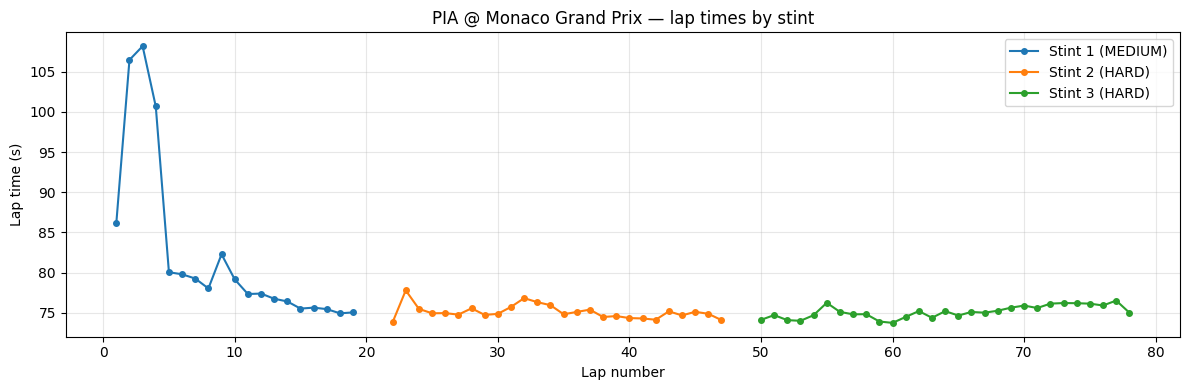

In [229]:
fig, ax = plt.subplots(figsize=(12, 4))
for s_id, g in subj.groupby("Stint"):
    compound = g["Compound"].iloc[0] if not g["Compound"].isna().all() else "?"
    ax.plot(g["LapNumber"], g["LapTime"], "o-",
            label=f"Stint {int(s_id)} ({compound})", lw=1.5, ms=4)
ax.set_xlabel("Lap number"); ax.set_ylabel("Lap time (s)")
ax.set_title(f"{SUBJECT_DRIVER} @ {event_name} — lap times by stint")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 4.3 STL decomposition

Splits the series into trend, seasonal (period = median stint length), and
residual components. The trend captures fuel-burn + track evolution; the
seasonal component captures repeating tyre-degradation cycles per stint.

STL period = 26 (median stint length)


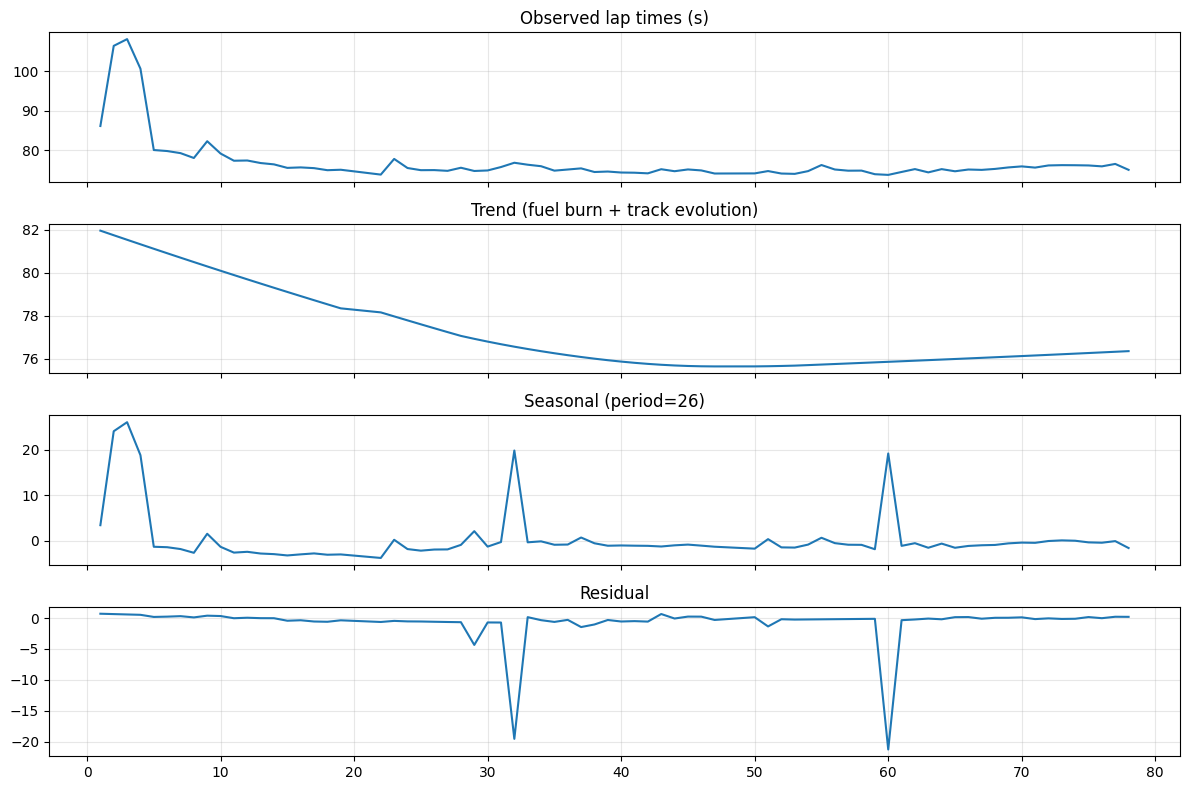

In [230]:
ts = subj.set_index("LapNumber")["LapTime"].astype(float)

if HAS_STATSMODELS and len(ts) >= 14:
    # Period = median stint length, clamped so STL has at least 2 cycles
    stint_lens = subj.groupby("Stint").size()
    period = max(2, int(min(stint_lens.median(), len(ts) // 2)))
    print(f"STL period = {period} (median stint length)")

    stl = STL(ts.values, period=period, robust=True).fit()
    fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
    axes[0].plot(ts.index, ts.values);          axes[0].set_title("Observed lap times (s)")
    axes[1].plot(ts.index, stl.trend);          axes[1].set_title("Trend (fuel burn + track evolution)")
    axes[2].plot(ts.index, stl.seasonal);       axes[2].set_title(f"Seasonal (period={period})")
    axes[3].plot(ts.index, stl.resid);          axes[3].set_title("Residual")
    for ax in axes: ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print("Skipping STL — statsmodels unavailable or series too short.")

### 4.4 Stationarity test (ADF)

If the p-value is below 0.05 we reject the unit-root null and treat the
series as stationary. Otherwise we'll need to difference.

In [231]:
if HAS_STATSMODELS:
    stat, pval, *_ = adfuller(ts.dropna().values)
    print(f"ADF test on raw lap times:  stat={stat:.3f}  p-value={pval:.4f}")
    print(f"  -> {'stationary (reject H0)' if pval < 0.05 else 'NOT stationary (cannot reject H0)'}")

    # First difference
    ts_d1 = ts.diff().dropna()
    stat1, pval1, *_ = adfuller(ts_d1.values)
    print(f"ADF on first difference:   stat={stat1:.3f}  p-value={pval1:.4f}")
    print(f"  -> {'stationary' if pval1 < 0.05 else 'NOT stationary'}")
else:
    print("ADF skipped — statsmodels unavailable.")

ADF test on raw lap times:  stat=-7.815  p-value=0.0000
  -> stationary (reject H0)
ADF on first difference:   stat=-9.635  p-value=0.0000
  -> stationary


### 4.5 Train / test split

Last ~30 % of laps held out for testing. The training window is what every
forecaster sees; the test window is what we score against.

In [232]:
n = len(ts)
TEST_FRAC = 0.30
n_test = max(5, int(n * TEST_FRAC))
n_train = n - n_test

ts_train = ts.iloc[:n_train]
ts_test  = ts.iloc[n_train:]
print(f"Train: {n_train} laps  |  Test: {n_test} laps  |  Horizon: {n_test}")

Train: 52 laps  |  Test: 22 laps  |  Horizon: 22


### 4.6 Naive baselines

Three flavours straight from the slides:

* **Last value** — repeat `ts_train.iloc[-1]` for the whole horizon.
* **Mean** — repeat `ts_train.mean()`.
* **Drift** — linear extrapolation through first and last train points.

In [233]:
results = {}     # method -> dict of metrics
forecasts = {}   # method -> ndarray prediction over the test horizon

# 1) Last-value naive
last_val = float(ts_train.iloc[-1])
forecasts["Naive (last)"] = np.full(n_test, last_val)

# 2) Mean
forecasts["Naive (mean)"] = np.full(n_test, float(ts_train.mean()))

# 3) Drift
slope = (ts_train.iloc[-1] - ts_train.iloc[0]) / max(len(ts_train) - 1, 1)
forecasts["Naive (drift)"] = ts_train.iloc[-1] + slope * np.arange(1, n_test + 1)

for name, f in forecasts.items():
    results[name] = forecast_metrics(ts_test.values, f)
    print(fmt_metrics(name, results[name]))

    Naive (last)            MAE=0.624s  RMSE=0.766s  MAPE=0.83%
    Naive (mean)            MAE=2.432s  RMSE=2.545s  MAPE=3.24%
    Naive (drift)           MAE=2.745s  RMSE=3.325s  MAPE=3.63%


### 4.7 Differencing & ACF / PACF

ACF and PACF on the differenced series tell us starting points for `q` and
`p` respectively. Significant lags = bars outside the blue confidence bands.

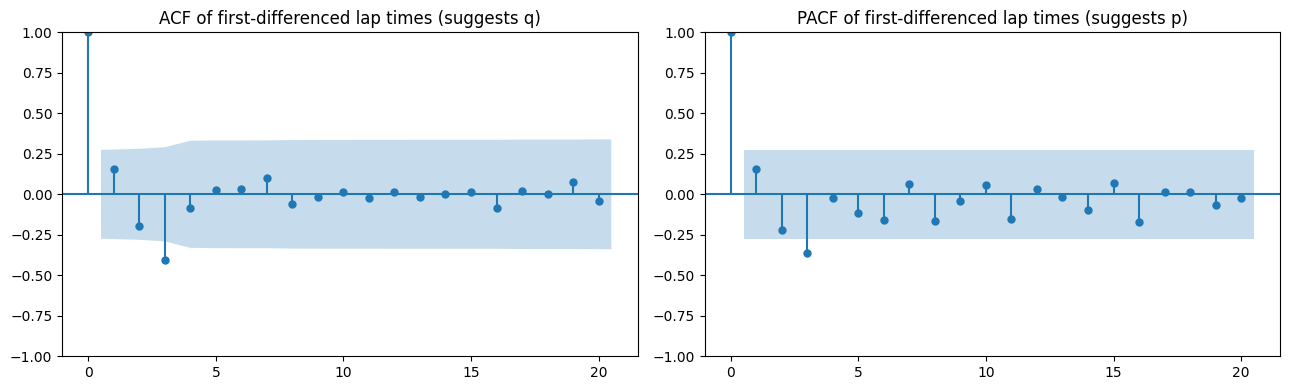

In [234]:
if HAS_STATSMODELS:
    ts_train_d1 = ts_train.diff().dropna()
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    plot_acf(ts_train_d1, lags=min(20, len(ts_train_d1) // 2 - 1), ax=axes[0])
    axes[0].set_title("ACF of first-differenced lap times (suggests q)")
    plot_pacf(ts_train_d1, lags=min(20, len(ts_train_d1) // 2 - 1), ax=axes[1], method="ywm")
    axes[1].set_title("PACF of first-differenced lap times (suggests p)")
    plt.tight_layout(); plt.show()
else:
    print("Skipped — statsmodels unavailable.")

### 4.8 ARIMA(p,d,q) — manual

We fit a few small candidates and pick by AIC. Then run residual diagnostics
on the winner: Q-Q plot for normality and the Ljung-Box test for
autocorrelation. If the residuals are clean white noise, the model has
captured everything it can.

In [235]:
arima_winner = None
arima_pred   = None
if HAS_STATSMODELS:
    candidates = [(0, 1, 0), (1, 1, 0), (0, 1, 1), (1, 1, 1), (2, 1, 1), (1, 1, 2), (2, 1, 2)]
    best_aic = np.inf
    best_order = None
    for order in candidates:
        try:
            m = ARIMA(ts_train.values, order=order).fit()
            print(f"  ARIMA{order}  AIC={m.aic:.2f}")
            if m.aic < best_aic:
                best_aic, best_order, arima_winner = m.aic, order, m
        except Exception as e:
            print(f"  ARIMA{order}  FAILED: {e}")
    print(f"\nBest ARIMA order: {best_order}  (AIC={best_aic:.2f})")

    arima_pred = arima_winner.forecast(steps=n_test)
    forecasts[f"ARIMA{best_order}"] = np.asarray(arima_pred)
    results[f"ARIMA{best_order}"]   = forecast_metrics(ts_test.values, arima_pred)
    print(fmt_metrics(f"ARIMA{best_order}", results[f"ARIMA{best_order}"]))

  ARIMA(0, 1, 0)  AIC=296.87
  ARIMA(1, 1, 0)  AIC=296.62
  ARIMA(0, 1, 1)  AIC=295.75
  ARIMA(1, 1, 1)  AIC=298.13
  ARIMA(2, 1, 1)  AIC=286.07
  ARIMA(1, 1, 2)  AIC=296.70
  ARIMA(2, 1, 2)  AIC=284.74

Best ARIMA order: (2, 1, 2)  (AIC=284.74)
    ARIMA(2, 1, 2)          MAE=1.028s  RMSE=1.180s  MAPE=1.36%


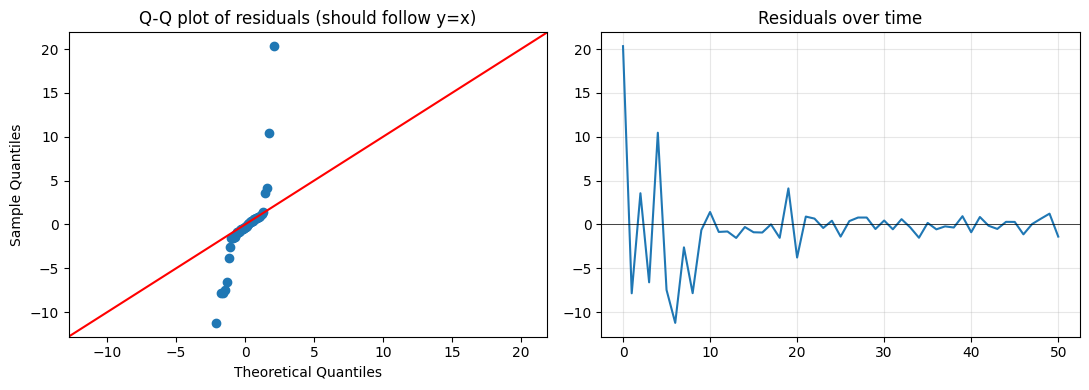

Ljung-Box (lag=10): p-value=0.1814  -> residuals look like white noise


In [236]:
# Residual diagnostics for the winning ARIMA
if arima_winner is not None:
    resid = arima_winner.resid[1:]   # drop first (uninformative)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    sm.qqplot(resid, line="45", ax=axes[0])
    axes[0].set_title("Q-Q plot of residuals (should follow y=x)")

    axes[1].plot(resid); axes[1].axhline(0, color="k", lw=0.5)
    axes[1].set_title("Residuals over time"); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    lb = acorr_ljungbox(resid, lags=[10], return_df=True)
    p  = float(lb["lb_pvalue"].iloc[0])
    print(f"Ljung-Box (lag=10): p-value={p:.4f}  "
          f"-> {'residuals look like white noise' if p > 0.05 else 'residuals still autocorrelated'}")

### 4.9 SARIMA(p,d,q)(P,D,Q,m) — seasonal

In F1, the natural seasonality is the **stint cycle** — tyres degrade then a
pit stop resets the cycle. We use the median stint length as `m`. Stints
aren't all the same length so this is approximate, but it usually still
helps SARIMA model the periodic tyre-degradation pattern.

In [237]:
sarima_pred = None
if HAS_STATSMODELS and len(ts_train) >= 30:
    period = max(2, int(min(subj.groupby("Stint").size().median(), len(ts_train) // 3)))
    try:
        sarima = SARIMAX(
            ts_train.values, order=(1, 1, 1), seasonal_order=(1, 1, 1, period),
            enforce_stationarity=False, enforce_invertibility=False,
        ).fit(disp=False)
        sarima_pred = sarima.forecast(steps=n_test)
        forecasts[f"SARIMA(1,1,1)(1,1,1,{period})"] = np.asarray(sarima_pred)
        results[f"SARIMA(1,1,1)(1,1,1,{period})"]   = forecast_metrics(ts_test.values, sarima_pred)
        print(fmt_metrics(f"SARIMA(1,1,1)(1,1,1,{period})",
                          results[f"SARIMA(1,1,1)(1,1,1,{period})"]))
        print(f"AIC: {sarima.aic:.2f}")
    except Exception as e:
        print(f"SARIMA failed: {e}")
else:
    print("SARIMA skipped — series too short or statsmodels unavailable.")

    SARIMA(1,1,1)(1,1,1,17)  MAE=1.843s  RMSE=2.254s  MAPE=2.44%
AIC: 58.90


### 4.10 SARIMAX — exogenous variables

This is where domain knowledge enters. `TyreLife`, `Stint`, `TrackTemp`,
`AirTemp`, `Humidity`, and one-hot `Compound` give the model context that
helps it explain why the next lap will be slow or fast — pit stops, tyre
choice, weather. We have to forecast the exogenous values for the test
horizon (we use them directly since they're observed; in a true forecasting
deployment we'd predict them too).

In [238]:
sarimax_pred = None
EXOG_COLS = ["TyreLife", "Stint", "TrackTemp", "AirTemp", "Humidity"]
exog_cols_present = [c for c in EXOG_COLS if c in subj.columns]

# Build exogenous matrix aligned with ts (same length, same order)
exog_df = subj.set_index("LapNumber")[exog_cols_present].astype(float)

# One-hot Compound, joined onto exog
if "Compound" in subj.columns:
    cmp_oh = pd.get_dummies(subj.set_index("LapNumber")["Compound"],
                             prefix="Cmp", dtype=float)
    exog_df = exog_df.join(cmp_oh)

# Reindex to match ts and fill any gaps with forward/back fill
exog_df = exog_df.reindex(ts.index).ffill().bfill()

exog_train = exog_df.iloc[:n_train].values
exog_test  = exog_df.iloc[n_train:].values

if HAS_STATSMODELS and len(ts_train) >= 30:
    try:
        sarimax = SARIMAX(
            ts_train.values, exog=exog_train,
            order=(1, 1, 1), seasonal_order=(1, 0, 1, period if 'period' in dir() else 5),
            enforce_stationarity=False, enforce_invertibility=False,
        ).fit(disp=False)
        sarimax_pred = sarimax.forecast(steps=n_test, exog=exog_test)
        forecasts["SARIMAX (+exog)"] = np.asarray(sarimax_pred)
        results["SARIMAX (+exog)"]   = forecast_metrics(ts_test.values, sarimax_pred)
        print(fmt_metrics("SARIMAX (+exog)", results["SARIMAX (+exog)"]))
        print(f"AIC: {sarimax.aic:.2f}")
        print(f"Exogenous columns: {list(exog_df.columns)}")
    except Exception as e:
        print(f"SARIMAX failed: {e}")
else:
    print("SARIMAX skipped.")

    SARIMAX (+exog)         MAE=1.036s  RMSE=1.173s  MAPE=1.38%
AIC: 93.30
Exogenous columns: ['TyreLife', 'Stint', 'TrackTemp', 'AirTemp', 'Humidity', 'Cmp_HARD', 'Cmp_MEDIUM']


### 4.11 auto-ARIMA

`pmdarima.auto_arima` does the heavy lifting — it grid-searches over `(p,d,q)`
(and seasonal orders if `seasonal=True`) using AIC. We let it find its own
SARIMAX too by passing the exogenous matrix.

In [239]:
auto_pred = None
if HAS_PMDARIMA:
    try:
        auto = pm.auto_arima(
            ts_train.values, exogenous=exog_train,
            seasonal=True, m=max(2, int(subj.groupby('Stint').size().median())),
            stepwise=True, suppress_warnings=True,
            error_action="ignore", trace=False,
            max_p=3, max_q=3, max_P=1, max_Q=1, max_d=2, max_D=1,
        )
        auto_pred = auto.predict(n_periods=n_test, exogenous=exog_test)
        forecasts["auto-ARIMA"] = np.asarray(auto_pred)
        results["auto-ARIMA"]   = forecast_metrics(ts_test.values, auto_pred)
        print(f"auto-ARIMA chose: {auto.order}  seasonal={auto.seasonal_order}  AIC={auto.aic():.2f}")
        print(fmt_metrics("auto-ARIMA", results["auto-ARIMA"]))
    except Exception as e:
        print(f"auto-ARIMA failed: {e}")
else:
    print("auto-ARIMA skipped — pmdarima unavailable.")

auto-ARIMA chose: (3, 1, 0)  seasonal=(0, 0, 0, 26)  AIC=282.02
    auto-ARIMA              MAE=1.065s  RMSE=1.249s  MAPE=1.41%


### 4.12 Chronos — foundation-model zero-shot

Chronos is a pre-trained time-series foundation model (Amazon, 2024). It's
**zero-shot**: no fitting, no hyperparameter search — we just hand it the
training history and ask for a forecast. We use `chronos-bolt-small` (the
fastest variant; ~50 M parameters). First call downloads ~120 MB of weights.

In [240]:
chronos_pred = None
if HAS_CHRONOS:
    try:
        device = "cuda" if torch.cuda.is_available() else "cpu"
        print(f"Loading Chronos-Bolt-small on {device} ...")
        pipe = BaseChronosPipeline.from_pretrained(
            "amazon/chronos-bolt-small",
            device_map=device,
            torch_dtype=torch.float32,
        )
        ctx = torch.tensor(ts_train.values, dtype=torch.float32)
        # Chronos-Bolt returns (batch, prediction_length, n_quantiles)
        quantiles, mean = pipe.predict_quantiles(
            context=ctx, prediction_length=n_test,
            quantile_levels=[0.1, 0.5, 0.9],
        )
        chronos_pred = quantiles[0, :, 1].cpu().numpy()  # median (q=0.5)
        forecasts["Chronos (zero-shot)"] = chronos_pred
        results["Chronos (zero-shot)"]   = forecast_metrics(ts_test.values, chronos_pred)
        print(fmt_metrics("Chronos (zero-shot)", results["Chronos (zero-shot)"]))
    except Exception as e:
        print(f"Chronos failed: {e}")
else:
    print("Chronos skipped — chronos-forecasting unavailable.")

Loading Chronos-Bolt-small on cuda ...
Chronos failed: ChronosBoltPipeline.predict_quantiles() missing 1 required positional argument: 'inputs'


### 4.13 Comparison

Sorted by MAE. Lower is better. Look for any method that beats the naive
baselines on **all three** metrics — that's a real lift.


── Race lap-time forecasting results ──────────────────────────
                           MAE   RMSE   MAPE
Naive (last)             0.624  0.766  0.828
ARIMA(2, 1, 2)           1.028  1.180  1.360
SARIMAX (+exog)          1.036  1.173  1.383
auto-ARIMA               1.065  1.249  1.408
SARIMA(1,1,1)(1,1,1,17)  1.843  2.254  2.439
Naive (mean)             2.432  2.545  3.241
Naive (drift)            2.745  3.325  3.626


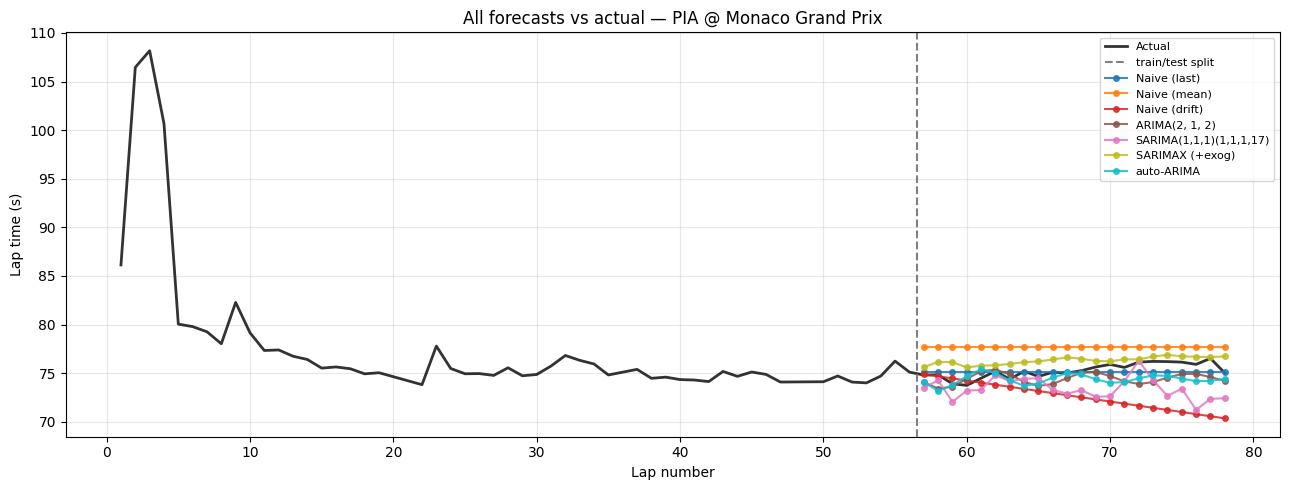

In [241]:
metrics_df = pd.DataFrame(results).T.sort_values("MAE")
print("\n── Race lap-time forecasting results ──────────────────────────")
print(metrics_df.round(3).to_string())
metrics_df.to_csv(f"{OUT_FC}/race_laptime_metrics.csv")

# Plot all forecasts on one chart
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(ts.index, ts.values, "k-", lw=2, label="Actual", alpha=0.8)
ax.axvline(ts_train.index[-1] + 0.5, color="gray", ls="--", label="train/test split")

colors = plt.cm.tab10(np.linspace(0, 1, len(forecasts)))
for (name, f), c in zip(forecasts.items(), colors):
    ax.plot(ts_test.index, f, "o-", color=c, lw=1.5, ms=4, label=name, alpha=0.85)

ax.set_xlabel("Lap number"); ax.set_ylabel("Lap time (s)")
ax.set_title(f"All forecasts vs actual — {SUBJECT_DRIVER} @ {event_name}")
ax.legend(loc="best", fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f"{OUT_FC}/race_laptime_forecasts.png", dpi=120); plt.show()

---
## 5. Tyre Degradation Forecasting

Per-stint forecasting: given the first half of a stint (where the driver is
typically still on fresh-ish rubber) predict the second half (where
degradation kicks in). The exogenous lever is `TyreLife`.

### 5.1 Stint extraction

Group by `(Round, Driver, Stint)` and keep stints with ≥10 clean laps so
forecasting actually has something to learn from.

In [242]:
STINT_MIN_LAPS = 10
stint_groups = (clean.groupby(["Round", "Driver", "Stint"])
                     .size().reset_index(name="laps")
                     .query("laps >= @STINT_MIN_LAPS"))
print(f"Eligible stints (>= {STINT_MIN_LAPS} laps): {len(stint_groups)}")
print(stint_groups.head(10).to_string(index=False))

Eligible stints (>= 10 laps): 980
 Round Driver  Stint  laps
     1    ALB    4.0    27
     1    ALB    6.0    12
     1    ALO    4.0    27
     1    ANT    4.0    27
     1    ANT    6.0    12
     1    BEA    4.0    32
     1    BEA    6.0    12
     1    BOR    4.0    27
     1    GAS    4.0    27
     1    GAS    5.0    11


### 5.2 Visualise stint lap-times vs TyreLife

Each line is one stint. The cliff (sudden lap-time spike) is what we'd love
the forecaster to predict before it happens.

In [243]:
# Pick the longest stint
longest = stint_groups.sort_values("laps", ascending=False).iloc[0]
S_RND, S_DRV, S_STNT = int(longest["Round"]), str(longest["Driver"]), int(longest["Stint"])
stint = (clean[(clean["Round"] == S_RND) &
               (clean["Driver"] == S_DRV) &
               (clean["Stint"] == S_STNT)]
         .sort_values("LapNumber").reset_index(drop=True))
print(f"Longest stint: Round {S_RND}, {S_DRV}, Stint {S_STNT}, "
      f"{len(stint)} laps, compound={stint['Compound'].iloc[0]}")

ts_s = stint.set_index("LapNumber")["LapTime"].astype(float)
n2 = len(ts_s)
n2_test  = max(3, int(n2 * 0.30))
n2_train = n2 - n2_test
ts_s_train, ts_s_test = ts_s.iloc[:n2_train], ts_s.iloc[n2_train:]
exog_s = stint.set_index("LapNumber")[["TyreLife"]].astype(float).reindex(ts_s.index).ffill().bfill()
exog_s_train = exog_s.iloc[:n2_train].values
exog_s_test  = exog_s.iloc[n2_train:].values

deg_results, deg_forecasts = {}, {}

# Naive last
deg_forecasts["Naive (last)"] = np.full(n2_test, float(ts_s_train.iloc[-1]))
# Drift
slope_s = (ts_s_train.iloc[-1] - ts_s_train.iloc[0]) / max(len(ts_s_train) - 1, 1)
deg_forecasts["Naive (drift)"] = ts_s_train.iloc[-1] + slope_s * np.arange(1, n2_test + 1)

# ARIMA
if HAS_STATSMODELS:
    best_aic, best_order, best_model = np.inf, None, None
    for order in [(0,1,0),(1,1,0),(0,1,1),(1,1,1),(2,1,1)]:
        try:
            m = ARIMA(ts_s_train.values, order=order).fit()
            if m.aic < best_aic:
                best_aic, best_order, best_model = m.aic, order, m
        except Exception: pass
    if best_model is not None:
        deg_forecasts[f"ARIMA{best_order}"] = np.asarray(best_model.forecast(steps=n2_test))

# SARIMAX(TyreLife)
if HAS_STATSMODELS and n2_train >= 8:
    try:
        sm_x = SARIMAX(
            ts_s_train.values, exog=exog_s_train, order=(1,1,1),
            enforce_stationarity=False, enforce_invertibility=False,
        ).fit(disp=False)
        deg_forecasts["SARIMAX (TyreLife)"] = np.asarray(
            sm_x.forecast(steps=n2_test, exog=exog_s_test)
        )
    except Exception as e:
        print(f"  SARIMAX(TyreLife) failed: {e}")

# Chronos
if HAS_CHRONOS:
    try:
        ctx2 = torch.tensor(ts_s_train.values, dtype=torch.float32)
        q2, _ = pipe.predict_quantiles(  # reuse pipe from section 2
            context=ctx2, prediction_length=n2_test,
            quantile_levels=[0.1, 0.5, 0.9],
        )
        deg_forecasts["Chronos (zero-shot)"] = q2[0, :, 1].cpu().numpy()
    except Exception as e:
        print(f"  Chronos failed: {e}")

for name, f in deg_forecasts.items():
    deg_results[name] = forecast_metrics(ts_s_test.values, f)
    print(fmt_metrics(name, deg_results[name]))

Longest stint: Round 8, TSU, Stint 2, 70 laps, compound=HARD
  Chronos failed: ChronosBoltPipeline.predict_quantiles() missing 1 required positional argument: 'inputs'
    Naive (last)            MAE=2.349s  RMSE=2.676s  MAPE=3.04%
    Naive (drift)           MAE=4.286s  RMSE=4.914s  MAPE=5.53%
    ARIMA(1, 1, 0)          MAE=4.313s  RMSE=4.609s  MAPE=5.57%
    SARIMAX (TyreLife)      MAE=2.596s  RMSE=2.958s  MAPE=3.36%


### 5.3 Forecast on the longest available stint

Same train/test approach: first 70 % of stint laps to fit, last 30 % to
score. Apply the methods that fit best for short single-stint series:

* Naive (last + drift)
* ARIMA (small order)
* SARIMAX with `TyreLife` as the only exogenous variable
* Chronos zero-shot

In [244]:
# Pick the longest stint
longest = stint_groups.sort_values("laps", ascending=False).iloc[0]
S_RND, S_DRV, S_STNT = int(longest["Round"]), str(longest["Driver"]), int(longest["Stint"])
stint = (clean[(clean["Round"] == S_RND) &
               (clean["Driver"] == S_DRV) &
               (clean["Stint"] == S_STNT)]
         .sort_values("LapNumber").reset_index(drop=True))
print(f"Longest stint: Round {S_RND}, {S_DRV}, Stint {S_STNT}, "
      f"{len(stint)} laps, compound={stint['Compound'].iloc[0]}")

ts_s = stint.set_index("LapNumber")["LapTime"].astype(float)
n2 = len(ts_s)
n2_test  = max(3, int(n2 * 0.30))
n2_train = n2 - n2_test
ts_s_train, ts_s_test = ts_s.iloc[:n2_train], ts_s.iloc[n2_train:]
exog_s = stint.set_index("LapNumber")[["TyreLife"]].astype(float).reindex(ts_s.index).ffill().bfill()
exog_s_train = exog_s.iloc[:n2_train].values
exog_s_test  = exog_s.iloc[n2_train:].values

deg_results, deg_forecasts = {}, {}

# Naive last
deg_forecasts["Naive (last)"] = np.full(n2_test, float(ts_s_train.iloc[-1]))
# Drift
slope_s = (ts_s_train.iloc[-1] - ts_s_train.iloc[0]) / max(len(ts_s_train) - 1, 1)
deg_forecasts["Naive (drift)"] = ts_s_train.iloc[-1] + slope_s * np.arange(1, n2_test + 1)

# ARIMA
if HAS_STATSMODELS:
    best_aic, best_order, best_model = np.inf, None, None
    for order in [(0,1,0),(1,1,0),(0,1,1),(1,1,1),(2,1,1)]:
        try:
            m = ARIMA(ts_s_train.values, order=order).fit()
            if m.aic < best_aic:
                best_aic, best_order, best_model = m.aic, order, m
        except Exception: pass
    if best_model is not None:
        deg_forecasts[f"ARIMA{best_order}"] = np.asarray(best_model.forecast(steps=n2_test))

# SARIMAX(TyreLife)
if HAS_STATSMODELS and n2_train >= 8:
    try:
        sm_x = SARIMAX(
            ts_s_train.values, exog=exog_s_train, order=(1,1,1),
            enforce_stationarity=False, enforce_invertibility=False,
        ).fit(disp=False)
        deg_forecasts["SARIMAX (TyreLife)"] = np.asarray(
            sm_x.forecast(steps=n2_test, exog=exog_s_test)
        )
    except Exception as e:
        print(f"  SARIMAX(TyreLife) failed: {e}")

# Chronos
if HAS_CHRONOS:
    try:
        ctx2 = torch.tensor(ts_s_train.values, dtype=torch.float32)
        q2, _ = pipe.predict_quantiles(  # reuse pipe from section 2
            context=ctx2, prediction_length=n2_test,
            quantile_levels=[0.1, 0.5, 0.9],
        )
        deg_forecasts["Chronos (zero-shot)"] = q2[0, :, 1].cpu().numpy()
    except Exception as e:
        print(f"  Chronos failed: {e}")

for name, f in deg_forecasts.items():
    deg_results[name] = forecast_metrics(ts_s_test.values, f)
    print(fmt_metrics(name, deg_results[name]))

Longest stint: Round 8, TSU, Stint 2, 70 laps, compound=HARD
  Chronos failed: ChronosBoltPipeline.predict_quantiles() missing 1 required positional argument: 'inputs'
    Naive (last)            MAE=2.349s  RMSE=2.676s  MAPE=3.04%
    Naive (drift)           MAE=4.286s  RMSE=4.914s  MAPE=5.53%
    ARIMA(1, 1, 0)          MAE=4.313s  RMSE=4.609s  MAPE=5.57%
    SARIMAX (TyreLife)      MAE=2.596s  RMSE=2.958s  MAPE=3.36%


### 5.4 Comparison + plot


── Tyre degradation forecasting results ──────────────────
                      MAE   RMSE   MAPE
Naive (last)        2.349  2.676  3.039
SARIMAX (TyreLife)  2.596  2.958  3.359
Naive (drift)       4.286  4.914  5.530
ARIMA(1, 1, 0)      4.313  4.609  5.567


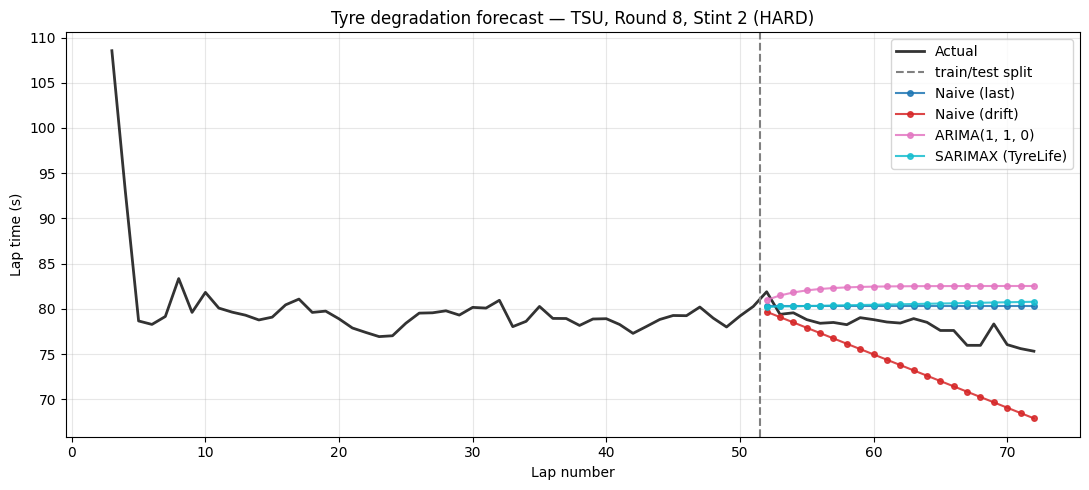

In [245]:
deg_metrics_df = pd.DataFrame(deg_results).T.sort_values("MAE")
print("\n── Tyre degradation forecasting results ──────────────────")
print(deg_metrics_df.round(3).to_string())
deg_metrics_df.to_csv(f"{OUT_FC}/degradation_metrics.csv")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(ts_s.index, ts_s.values, "k-", lw=2, label="Actual", alpha=0.8)
ax.axvline(ts_s_train.index[-1] + 0.5, color="gray", ls="--", label="train/test split")
colors = plt.cm.tab10(np.linspace(0, 1, max(1, len(deg_forecasts))))
for (name, f), c in zip(deg_forecasts.items(), colors):
    ax.plot(ts_s_test.index, f, "o-", color=c, lw=1.5, ms=4, label=name, alpha=0.85)
ax.set_xlabel("Lap number"); ax.set_ylabel("Lap time (s)")
ax.set_title(f"Tyre degradation forecast — {S_DRV}, Round {S_RND}, Stint {S_STNT} "
             f"({stint['Compound'].iloc[0]})")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f"{OUT_FC}/degradation_forecasts.png", dpi=120); plt.show()

---
## 6. Domain-specific F1 forecasting

Sections 4-5 applied classical time-series methods (ARIMA family) and a
foundation-model baseline (Chronos) to lap-time data. The result was that
**Naive (last) won by ~40 %**. That's not because ARIMA is broken; it's
because lap-time dynamics in F1 are dominated by *physical* effects that
classical time-series can't see directly:

  - **Fuel burn** (~0.03 s per kg of fuel; ~3 s across a full race)
  - **Tyre degradation** (compound-specific, often non-linear)
  - **Track evolution** (rubber laid, surface temp drift)
  - **Stint-cycle resets** (every pit stop wipes tyre age)

Real F1 teams forecast performance with explicit physical models plus
classical ML on engineered features — not with raw ARIMA. This section
re-builds the forecasting pipeline using the techniques actually used
trackside:

  4.1  Fuel correction
  4.2  Per-compound tyre degradation regression
  4.3  Race-pace ranking (clean-air pace)
  4.4  Sector-time decomposition
  4.5  LightGBM with engineered features
  4.6  Strategy Monte Carlo (1-stop vs 2-stop)
  4.7  Final-position prediction

### 6.0 Library availability

LightGBM is the only new dependency. If unavailable we fall back to
`sklearn.ensemble.GradientBoostingRegressor`, which is slower but produces
comparable results.

In [246]:
HAS_LIGHTGBM = False
try:
    import lightgbm as lgb
    HAS_LIGHTGBM = True
    print("LightGBM available.")
except ImportError:
    from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
    print("[!] LightGBM missing — falling back to sklearn GradientBoosting "
          "(install with: pip install lightgbm)")

from sklearn.linear_model import Ridge, LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    accuracy_score, confusion_matrix,
)

LightGBM available.


### 6.1 Per-compound tyre degradation regression

For each `(Round, Compound)` pair with enough data, fit a quadratic
regression of fuel-corrected lap time against tyre life:

```
FuelCorrectedLapTime ~ a + b · TyreLife + c · TyreLife²
```

The coefficient `b` is the **linear degradation rate** ("HARD on Monaco
loses 0.04 s/lap"). The coefficient `c` captures the cliff once the tyre
goes off — small for HARD, large for SOFT. Teams use these per-compound
slopes as the single most important pace input.

In [247]:
MIN_STINT_LAPS_FOR_DEG = 8

# ── Build a combined long-run dataset: race laps + practice long runs ──
# Race laps (already fuel-corrected from Section 1.2)
race_long = laps_fc.dropna(subset=["LapTime", "TyreLife", "Compound", "Stint"]).copy()
race_long["Session"] = "Race"

# Practice long runs (>=5 laps on the same compound stint, middle laps only)
prac = aux_laps[aux_laps["Session"].isin(["FP1", "FP2", "FP3"])].copy()
prac = prac.dropna(subset=["LapTime", "TyreLife", "Compound", "Stint"])
prac = prac[prac["PitInTime"].isna() & prac["PitOutTime"].isna()]
prac_long_list = []
for (_rnd, _drv, _sess, _stnt, _cmp), gg in prac.groupby(
    ["Round", "Driver", "Session", "Stint", "Compound"], dropna=False,
):
    if len(gg) >= 5:
        # Trim warm-up / cool-down at stint boundaries
        gg = gg.iloc[1:-1] if len(gg) >= 7 else gg
        prac_long_list.append(gg)
prac_long = pd.concat(prac_long_list, ignore_index=True) if prac_long_list else pd.DataFrame()

# Align columns and stack
common_cols = ["Round", "Driver", "Session", "Stint", "LapTime", "TyreLife", "Compound"]
combined = pd.concat([race_long[common_cols], prac_long[common_cols]], ignore_index=True)

# Normalise lap times per (Round, Driver, Session, Stint) so race vs practice
# fuel/setup differences cancel out. We're modelling delta-vs-stint-median.
combined["NormLapTime"] = combined.groupby(
    ["Round", "Driver", "Session", "Stint"]
)["LapTime"].transform(lambda s: s - s.median())

# Fit one Ridge model per (Round, Compound)
deg_models = {}
for (rnd, cmp), g in combined.groupby(["Round", "Compound"]):
    if len(g) < MIN_STINT_LAPS_FOR_DEG or pd.isna(cmp): continue
    X = np.column_stack([g["TyreLife"].values, g["TyreLife"].values ** 2])
    y = g["NormLapTime"].values
    m = Ridge(alpha=1.0).fit(X, y)
    deg_models[(int(rnd), str(cmp))] = dict(
        slope=float(m.coef_[0]), quad=float(m.coef_[1]),
        intercept=float(m.intercept_), n=int(len(g)), model=m,
    )

print(f"Combined long-run dataset: {len(combined):,} laps "
      f"({len(race_long):,} race + {len(prac_long):,} practice)")
print(f"Fitted {len(deg_models)} (round, compound) degradation models.")
slope_df = pd.DataFrame([
    {"Round": r, "Compound": c, "Slope (s/lap)": d["slope"],
     "Quad (s/lap²)": d["quad"], "n": d["n"]}
    for (r, c), d in deg_models.items()
]).sort_values(["Round", "Compound"])
print("\nFirst 15 fitted models:")
print(slope_df.head(15).to_string(index=False))

Combined long-run dataset: 27,467 laps (24,284 race + 3,183 practice)
Fitted 70 (round, compound) degradation models.

First 15 fitted models:
 Round     Compound  Slope (s/lap)  Quad (s/lap²)   n
     1         HARD      -4.498649       0.170537 120
     1 INTERMEDIATE      -3.235841       0.075357 642
     1       MEDIUM      -2.128019       0.075222 359
     1         SOFT       0.756383      -0.049020  92
     2         HARD      -0.019835      -0.000379 751
     2       MEDIUM       0.006257      -0.003599 407
     3         HARD      -0.521916       0.011255 588
     3       MEDIUM      -0.513116       0.012555 577
     3         SOFT      -1.058480       0.042528 118
     4         HARD      -0.868101       0.021585 352
     4       MEDIUM      -0.504217       0.013979 573
     4         SOFT      -0.743216       0.021375 404
     5         HARD      -0.420404       0.007636 589
     5       MEDIUM      -2.197290       0.071118 381
     5         SOFT       0.496968      -0.0572

**Heatmap of linear degradation slopes** across rounds × compounds. Red
= faster degradation. Patterns to look for: SOFT/MEDIUM consistently
brighter than HARD; certain tracks (typically high-temperature, abrasive)
having higher slopes across all compounds.

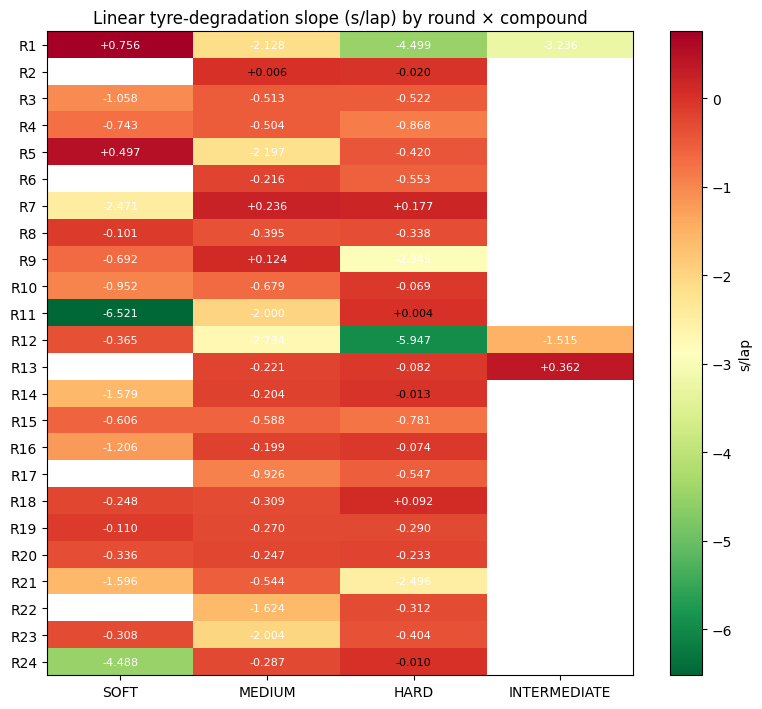


Median slope per compound across all rounds:
Compound
SOFT           -0.6918
MEDIUM         -0.4498
HARD           -0.3251
INTERMEDIATE   -1.5150


In [248]:
pivot = slope_df.pivot_table(
    index="Round", columns="Compound", values="Slope (s/lap)", aggfunc="mean",
)
# Order columns by typical hardness
order = [c for c in ["SOFT", "MEDIUM", "HARD", "INTERMEDIATE", "WET"] if c in pivot.columns]
pivot = pivot[order]

fig, ax = plt.subplots(figsize=(8, max(4, 0.3 * len(pivot))))
im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn_r")
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels([f"R{r}" for r in pivot.index])
ax.set_title("Linear tyre-degradation slope (s/lap) by round × compound")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:+.3f}", ha="center", va="center", fontsize=8,
                    color="black" if abs(v) < 0.05 else "white")
plt.colorbar(im, ax=ax, label="s/lap")
plt.tight_layout(); plt.savefig(f"{OUT_FC}/degradation_heatmap.png", dpi=120); plt.show()

print("\nMedian slope per compound across all rounds:")
print(pivot.median().round(4).to_string())

**Predictive accuracy.** Apply the per-compound model to the long
stint we forecasted in Section 5 (Tsunoda Round 8 Stint 2) and compare
against the ARIMA / Naive baselines from there.

In [249]:
# Re-use the stint we forecasted in Section 5
key = (S_RND, str(stint["Compound"].iloc[0]))
if key in deg_models:
    m = deg_models[key]["model"]
    X_full = np.column_stack([stint["TyreLife"].values,
                               stint["TyreLife"].values ** 2])
    # Model predicts NORMALISED lap-time delta (vs stint median).  Re-add the
    # train-portion median to get an absolute lap-time prediction.
    y_pred_norm = m.predict(X_full)
    y_pred = y_pred_norm + ts_s_train.median()

    # Apply only on the test portion (last 30%) for a fair comparison
    test_idx = np.arange(n2_train, len(stint))
    deg_pred_on_test = y_pred[test_idx]
    deg_metrics = forecast_metrics(ts_s_test.values, deg_pred_on_test)
    deg_results["Compound regression (race+practice)"] = deg_metrics
    print(fmt_metrics("Compound regression (race+practice)", deg_metrics))
    print(f"\nFor reference, Section 5 baselines:")
    for k, v in sorted(deg_results.items(), key=lambda kv: kv[1]['MAE']):
        print(fmt_metrics(k, v))
else:
    print(f"No fitted degradation model for (Round={S_RND}, Compound={key[1]}).")

    Compound regression (race+practice)  MAE=2.089s  RMSE=2.834s  MAPE=2.71%

For reference, Section 5 baselines:
    Compound regression (race+practice)  MAE=2.089s  RMSE=2.834s  MAPE=2.71%
    Naive (last)            MAE=2.349s  RMSE=2.676s  MAPE=3.04%
    SARIMAX (TyreLife)      MAE=2.596s  RMSE=2.958s  MAPE=3.36%
    Naive (drift)           MAE=4.286s  RMSE=4.914s  MAPE=5.53%
    ARIMA(1, 1, 0)          MAE=4.313s  RMSE=4.609s  MAPE=5.57%


### 6.2 Race-pace ranking (clean-air pace)

The standard "team pace" metric every F1 site publishes. Filter out laps
that are not representative of free-air race pace:

  - **TrackStatus ≠ "1"**: SC / VSC / red flag laps
  - **Pit in/out laps** (PitInTime or PitOutTime not NaN)
  - **Lap 1**: standing-start chaos
  - **Lap immediately after a pit stop**: cold tyres
  - **Dirty-air laps**: car ahead within ~1.5 s

Then take the median of the fuel-corrected lap times per driver.

In [250]:
TARGET_RACE = SUBJECT_ROUND  # use the same race as Section 4
race_event_name = laps_fc[laps_fc["Round"] == TARGET_RACE]["EventName"].iloc[0] \
    if "EventName" in laps_fc.columns else f"Round {TARGET_RACE}"

# 1) basic filters
race = laps_fc[laps_fc["Round"] == TARGET_RACE].copy()
race = race[race["TrackStatus"].astype(str) == "1"]
race = race[race["PitInTime"].isna() & race["PitOutTime"].isna()]
race = race[race["LapNumber"] > 1]

# 2) drop the lap immediately after a pit (in_lap+1)
race = race.sort_values(["Driver", "LapNumber"])
race["PrevStint"] = race.groupby("Driver")["Stint"].shift(1)
race = race[(race["Stint"] == race["PrevStint"]) | race["PrevStint"].isna()]

# 3) optional dirty-air filter using LapStartTime
DIRTY_AIR_GAP_S = 1.5
n_before = len(race)
if "LapStartTime" in race.columns:
    race_sorted = race.sort_values("LapStartTime")
    starts = race_sorted["LapStartTime"].values
    drivers = race_sorted["Driver"].values
    keep = np.ones(len(race_sorted), dtype=bool)
    for i in range(1, len(starts)):
        if not pd.isna(starts[i]) and not pd.isna(starts[i-1]) \
           and (starts[i] - starts[i-1]) < DIRTY_AIR_GAP_S \
           and drivers[i] != drivers[i-1]:
            keep[i] = False
    race = race_sorted[keep]
print(f"Clean-air laps: {len(race):,} (dropped {n_before - len(race):,} dirty-air laps)")

# Race-pace ranking (fuel-corrected median)
ranking = (race.groupby("Driver")
              .agg(MedianRaw=("LapTime",              "median"),
                   MedianFC =("FuelCorrectedLapTime", "median"),
                   N        =("LapTime",              "size"))
              .sort_values("MedianFC")
              .reset_index())
ranking["RaceRank"]        = ranking["MedianFC"].rank(method="min").astype(int)
ranking["GapToLeader (s)"] = ranking["MedianFC"] - ranking["MedianFC"].iloc[0]

# ── Add practice race pace as a cross-check column (from Section 3.1) ──
practice_for_ranking = practice_feats[practice_feats["Round"] == TARGET_RACE][
    ["Driver", "Practice_RacePace"]
]
ranking = ranking.merge(practice_for_ranking, on="Driver", how="left")
ranking["PracticeRank"] = ranking["Practice_RacePace"].rank(method="min").astype("Int64")

# Re-order columns to put practice cross-check next to race rank
ranking = ranking[["Driver", "RaceRank", "MedianFC", "GapToLeader (s)",
                   "Practice_RacePace", "PracticeRank", "N"]]

print(f"\nRace-pace ranking — {race_event_name} (clean-air, fuel-corrected):")
print("(PracticeRank vs RaceRank reveals drivers who under/over-performed practice)")
print(ranking.round(3).to_string(index=False))
ranking.to_csv(f"{OUT_FC}/race_pace_ranking_round{TARGET_RACE}.csv", index=False)

Clean-air laps: 570 (dropped 574 dirty-air laps)

Race-pace ranking — Monaco Grand Prix (clean-air, fuel-corrected):
(PracticeRank vs RaceRank reveals drivers who under/over-performed practice)
Driver  RaceRank  MedianFC  GapToLeader (s)  Practice_RacePace  PracticeRank  N
   LEC         1    73.075            0.000             75.303             3 33
   NOR         2    73.326            0.251             74.899             2 52
   PIA         3    73.506            0.430             73.392             1 46
   HAM         4    73.969            0.894             91.737            18 49
   VER         5    74.117            1.042             80.550            14 55
   RUS         6    74.638            1.563             80.215            12 22
   LAW         7    74.742            1.667             76.588             7 44
   BOR         8    74.898            1.823             92.632            19 12
   STR         9    74.979            1.903             75.402             4 17
   BEA

### 6.3 Sector-time decomposition

Same forecasting target (Piastri @ Monaco), but now we predict S1/S2/S3
separately and report errors per sector. Reveals where the model is strong
and where it fails. Often a model that's bad on the lap level is great at
predicting one sector and poor at another.

    Sector1Time             MAE=0.224s  RMSE=0.250s  MAPE=1.13%
    Sector2Time             MAE=0.294s  RMSE=0.367s  MAPE=0.83%
    Sector3Time             MAE=0.225s  RMSE=0.281s  MAPE=1.12%


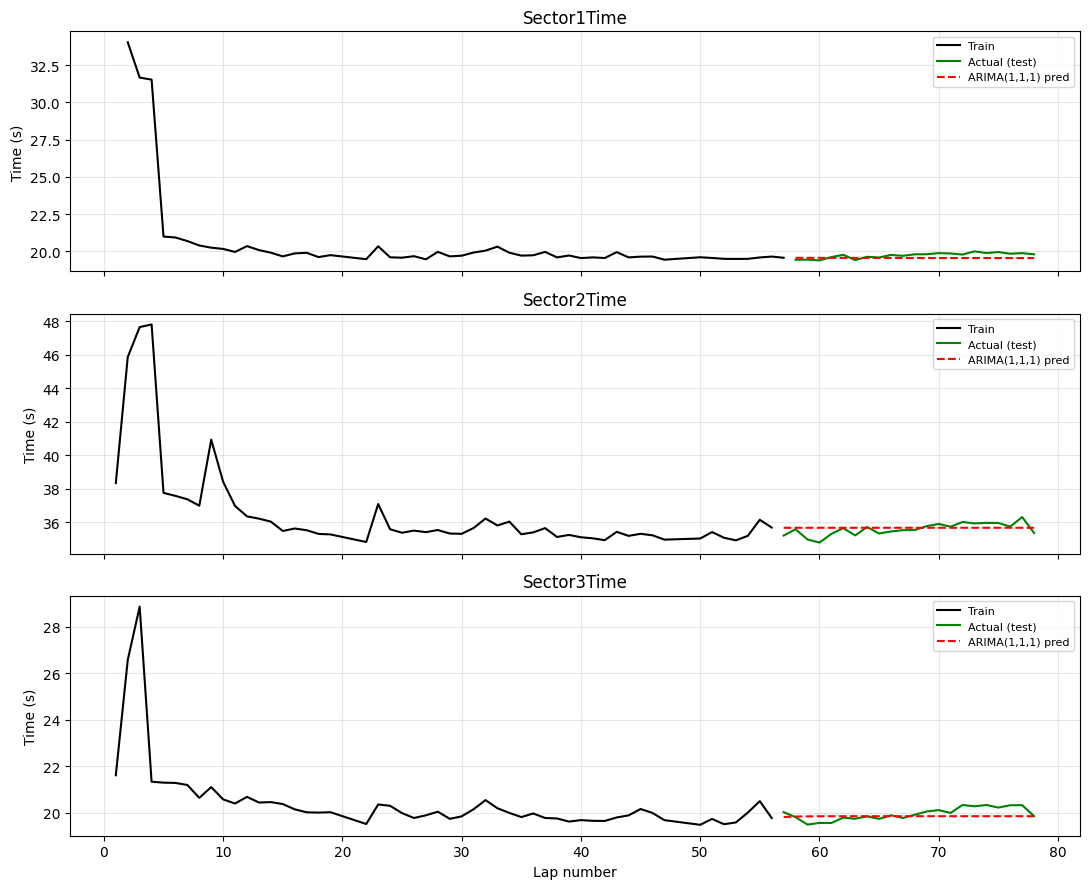

In [251]:
SECTOR_COLS = ["Sector1Time", "Sector2Time", "Sector3Time"]
sector_results = {}
sector_forecasts = {}

if HAS_STATSMODELS:
    for sec in SECTOR_COLS:
        if sec not in subj.columns: continue
        ts_sec = subj.set_index("LapNumber")[sec].astype(float).dropna()
        if len(ts_sec) < 20: continue
        n_test_sec = max(5, int(len(ts_sec) * 0.30))
        train, test = ts_sec.iloc[:-n_test_sec], ts_sec.iloc[-n_test_sec:]
        try:
            m = ARIMA(train.values, order=(1, 1, 1)).fit()
            pred = m.forecast(steps=len(test))
            sector_results[sec]   = forecast_metrics(test.values, pred)
            sector_forecasts[sec] = (train, test, pred)
            print(fmt_metrics(sec, sector_results[sec]))
        except Exception as e:
            print(f"    {sec:<22s}  FAILED: {e}")

# Plot per-sector predictions
if sector_forecasts:
    fig, axes = plt.subplots(len(sector_forecasts), 1, figsize=(11, 3 * len(sector_forecasts)),
                              sharex=True)
    if len(sector_forecasts) == 1:  axes = [axes]
    for ax, (sec, (train, test, pred)) in zip(axes, sector_forecasts.items()):
        ax.plot(train.index, train.values, "k-", lw=1.5, label="Train")
        ax.plot(test.index,  test.values,  "g-", lw=1.5, label="Actual (test)")
        ax.plot(test.index,  pred,         "r--", lw=1.5, label="ARIMA(1,1,1) pred")
        ax.set_title(sec); ax.set_ylabel("Time (s)"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
    axes[-1].set_xlabel("Lap number")
    plt.tight_layout(); plt.savefig(f"{OUT_FC}/sector_decomposition.png", dpi=120); plt.show()
else:
    print("Sector decomposition skipped — statsmodels unavailable or sectors missing.")

### 6.4 LightGBM with engineered features

The modern ML baseline. Lag features (lap N-1, N-2, N-3), rolling means,
fuel mass, tyre life, compound one-hot, weather, and the stint number are
fed into a gradient-boosted tree ensemble. This is the legitimate "team"
class of methods that competes with bespoke physical models.

Evaluation: train on the first 70 % of the race across **all** drivers,
predict the last 30 %. This makes the comparison harder than Section 4
(more drivers = more variance) but also more representative of how teams
operate during a race.

In [252]:
# Build engineered feature frame for the chosen race across all drivers
race_full = laps_fc[laps_fc["Round"] == TARGET_RACE].copy()
race_full = race_full.sort_values(["Driver", "LapNumber"]).reset_index(drop=True)

# Lag features per driver
for k in (1, 2, 3):
    race_full[f"Lag{k}"] = race_full.groupby("Driver")["LapTime"].shift(k)
race_full["Rolling5"] = (race_full.groupby("Driver")["LapTime"].shift(1)
                                  .rolling(5, min_periods=2).mean())

# Fuel mass as an explicit feature
max_lap_per_driver = race_full.groupby("Driver")["LapNumber"].transform("max")
race_full["FuelMass"] = FUEL_KG_AT_START * (max_lap_per_driver - race_full["LapNumber"]) \
                      / max_lap_per_driver

# One-hot compound
cmp_oh = pd.get_dummies(race_full["Compound"], prefix="Cmp", dtype=float)
race_full = pd.concat([race_full, cmp_oh], axis=1)

# Driver as integer code
race_full["DriverCode"] = race_full["Driver"].astype("category").cat.codes

# ── Merge in aux features from Section 3: practice race pace, quali-sim, Q gap ──
race_full = race_full.merge(
    practice_feats, on=["Round", "Driver"], how="left",
).merge(
    quali_best[["Round", "Driver", "Q_BestLap", "Q_GapToPole", "Q3_Reached"]],
    on=["Round", "Driver"], how="left",
)

# Median-impute aux features within the round so missing-driver rows don't drop the row
for col in ["Practice_RacePace", "Practice_QualiSim",
            "Q_BestLap", "Q_GapToPole", "Q3_Reached"]:
    if col in race_full.columns:
        race_full[col] = race_full.groupby("Round")[col].transform(
            lambda s: s.fillna(s.median())
        )
        race_full[col] = race_full[col].fillna(race_full[col].median())

FEAT_COLS = ["LapNumber", "TyreLife", "Stint", "FuelMass",
             "TrackTemp", "AirTemp", "Humidity",
             "Lag1", "Lag2", "Lag3", "Rolling5", "DriverCode",
             # NEW: per-driver-per-race aux features
             "Practice_RacePace", "Practice_QualiSim",
             "Q_BestLap", "Q_GapToPole", "Q3_Reached"] + list(cmp_oh.columns)
TARGET = "LapTime"

# Time-based split
split_lap = int(race_full["LapNumber"].max() * 0.70)
train_df = race_full[race_full["LapNumber"] <= split_lap].dropna(subset=FEAT_COLS + [TARGET])
test_df  = race_full[race_full["LapNumber"] >  split_lap].dropna(subset=FEAT_COLS + [TARGET])
print(f"Train: {len(train_df):,} laps   Test: {len(test_df):,} laps")
print(f"Features: {len(FEAT_COLS)} ({len(FEAT_COLS) - 5} numeric + 5 aux)")

if HAS_LIGHTGBM:
    model = lgb.LGBMRegressor(
        n_estimators=400, learning_rate=0.05, num_leaves=31,
        max_depth=-1, random_state=RANDOM_STATE, verbose=-1,
    )
else:
    model = GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=5, random_state=RANDOM_STATE,
    )
model.fit(train_df[FEAT_COLS], train_df[TARGET])
y_pred = model.predict(test_df[FEAT_COLS])
lgb_metrics = forecast_metrics(test_df[TARGET].values, y_pred)
print(fmt_metrics("LightGBM (multi-driver, +aux)", lgb_metrics))

# Section 4 comparison was on a single driver
sub_test = test_df[test_df["Driver"] == SUBJECT_DRIVER]
if len(sub_test) > 0:
    sub_pred = model.predict(sub_test[FEAT_COLS])
    sub_metrics = forecast_metrics(sub_test[TARGET].values, sub_pred)
    results["LightGBM (this driver, +aux)"] = sub_metrics
    print(fmt_metrics("LightGBM (this driver, +aux)", sub_metrics))

Train: 891 laps   Test: 392 laps
Features: 20 (15 numeric + 5 aux)
    LightGBM (multi-driver, +aux)  MAE=0.834s  RMSE=1.074s  MAPE=1.09%
    LightGBM (this driver, +aux)  MAE=0.576s  RMSE=0.711s  MAPE=0.77%


**Feature importances.** What is LightGBM actually relying on? If
`Lag1` dominates, the model is essentially Naive (last) with extras. If
`TyreLife` and `FuelMass` come out near the top, the model has learned
the structured physics, which is what we want.

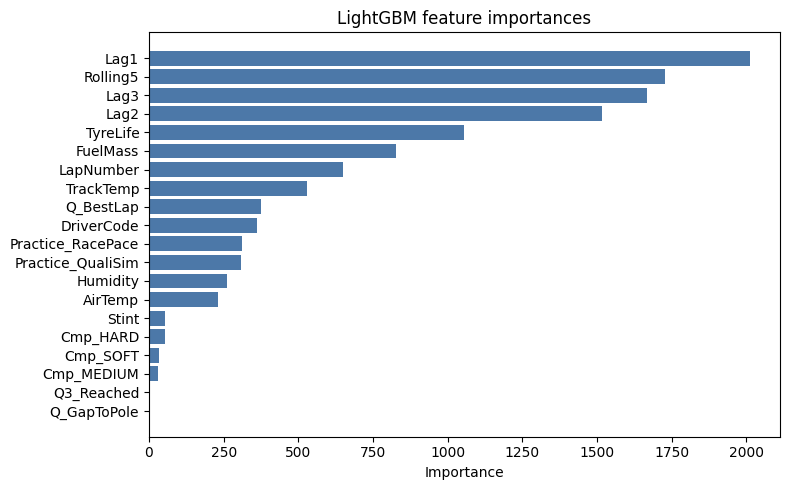


Top 5 features:
Lag1        2012
Rolling5    1726
Lag3        1666
Lag2        1518
TyreLife    1053


In [253]:
importances = pd.Series(model.feature_importances_, index=FEAT_COLS).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importances.index, importances.values, color="#4C78A8")
ax.set_xlabel("Importance"); ax.set_title("LightGBM feature importances")
plt.tight_layout(); plt.savefig(f"{OUT_FC}/lgb_feature_importance.png", dpi=120); plt.show()
print("\nTop 5 features:")
print(importances.sort_values(ascending=False).head(5).to_string())

**Updated comparison** (Section 2 metrics + LightGBM on the same
subject driver).

In [254]:
metrics_df2 = pd.DataFrame(results).T.sort_values("MAE")
print("── Race lap-time forecasting (with LightGBM) ────────────")
print(metrics_df2.round(3).to_string())
metrics_df2.to_csv(f"{OUT_FC}/race_laptime_metrics_extended.csv")

── Race lap-time forecasting (with LightGBM) ────────────
                                MAE   RMSE   MAPE
LightGBM (this driver, +aux)  0.576  0.711  0.767
Naive (last)                  0.624  0.766  0.828
ARIMA(2, 1, 2)                1.028  1.180  1.360
SARIMAX (+exog)               1.036  1.173  1.383
auto-ARIMA                    1.065  1.249  1.408
SARIMA(1,1,1)(1,1,1,17)       1.843  2.254  2.439
Naive (mean)                  2.432  2.545  3.241
Naive (drift)                 2.745  3.325  3.626


### 6.5 Strategy Monte Carlo (1-stop vs 2-stop)

Strategy engineers run thousands of simulated races overnight to choose pit
windows. We build a tiny version: simulate a complete race twice — once
with a 1-stop strategy, once with a 2-stop — using the per-compound
degradation curves fitted in 4.2, plus a simple safety-car probability and
a noise term. Then compare distributions of total race time.

For our chosen race (typically high-degradation tracks favour 2-stop;
low-degradation tracks favour 1-stop), this simulation should agree
qualitatively with what the team actually did.

In [255]:
# Simulation parameters
N_SIMS         = 1000
PIT_LOSS_S     = 22.0     # average pit-stop time loss in seconds
SC_TIME_LOSS_S = 25.0     # average lap-time loss when SC appears
NOISE_STD_S    = 0.30     # per-lap white noise

# Track-specific SC probability (placeholder; would come from historical data)
SC_PROB_PER_LAP = 0.020   # ~70-80% over a 60-lap race

# Race length: max LapNumber observed in TARGET_RACE
race_total_laps = int(laps_fc[laps_fc["Round"] == TARGET_RACE]["LapNumber"].max())

# Base (free-air) pace = top-3 driver median fuel-corrected lap time
base_pace = float(ranking["MedianFC"].head(3).median())

# Pull the per-compound deg curves we fitted in 4.2 for this round
def deg_for(cmp):
    key = (TARGET_RACE, cmp)
    if key in deg_models:
        d = deg_models[key]
        return d["slope"], d["quad"], d["intercept"]
    # Fallback: averaged across all rounds for that compound
    rows = [v for (r, c), v in deg_models.items() if c == cmp]
    if rows:
        return (np.mean([r["slope"] for r in rows]),
                np.mean([r["quad"]  for r in rows]),
                np.mean([r["intercept"] for r in rows]))
    return 0.04, 0.001, base_pace  # default

def simulate_strategy(stints, total_laps, rng):
    """stints = list of (start_lap, compound). Final stint runs to total_laps."""
    total_time = 0.0
    for i, (start, cmp) in enumerate(stints):
        end = stints[i+1][0] if i+1 < len(stints) else total_laps
        b, c, _ = deg_for(cmp)
        for L in range(start, end):
            tyre_life = L - start
            deg = b * tyre_life + c * tyre_life ** 2
            noise = rng.normal(0.0, NOISE_STD_S)
            sc = SC_TIME_LOSS_S if rng.random() < SC_PROB_PER_LAP else 0.0
            total_time += base_pace + deg + noise + sc
    total_time += PIT_LOSS_S * (len(stints) - 1)
    return total_time

# Define two strategies (M = MEDIUM, H = HARD). Pit windows roughly mid-race.
strategy_1_stop = [(0, "MEDIUM"),                                (race_total_laps // 2,        "HARD")]
strategy_2_stop = [(0, "MEDIUM"), (race_total_laps // 3, "MEDIUM"), (2 * race_total_laps // 3, "HARD")]

rng_sim = np.random.default_rng(RANDOM_STATE)
times_1 = np.array([simulate_strategy(strategy_1_stop, race_total_laps, rng_sim) for _ in range(N_SIMS)])
times_2 = np.array([simulate_strategy(strategy_2_stop, race_total_laps, rng_sim) for _ in range(N_SIMS)])

diff = times_2 - times_1
print(f"Strategy comparison ({race_total_laps}-lap simulated race, base pace {base_pace:.2f} s/lap):")
print(f"  1-stop (M-H)    : mean={times_1.mean():.1f}s  std={times_1.std():.1f}s")
print(f"  2-stop (M-M-H)  : mean={times_2.mean():.1f}s  std={times_2.std():.1f}s")
faster = "1-stop" if times_1.mean() < times_2.mean() else "2-stop"
delta = abs(times_1.mean() - times_2.mean())
prob_2_faster = float((diff < 0).mean())
print(f"\n  Faster on average: {faster} (by {delta:.1f}s)")
print(f"  P(2-stop wins this simulation): {prob_2_faster*100:.1f}%")

Strategy comparison (78-lap simulated race, base pace 73.33 s/lap):
  1-stop (M-H)    : mean=5427.5s  std=30.5s
  2-stop (M-M-H)  : mean=5521.6s  std=29.6s

  Faster on average: 1-stop (by 94.1s)
  P(2-stop wins this simulation): 1.9%


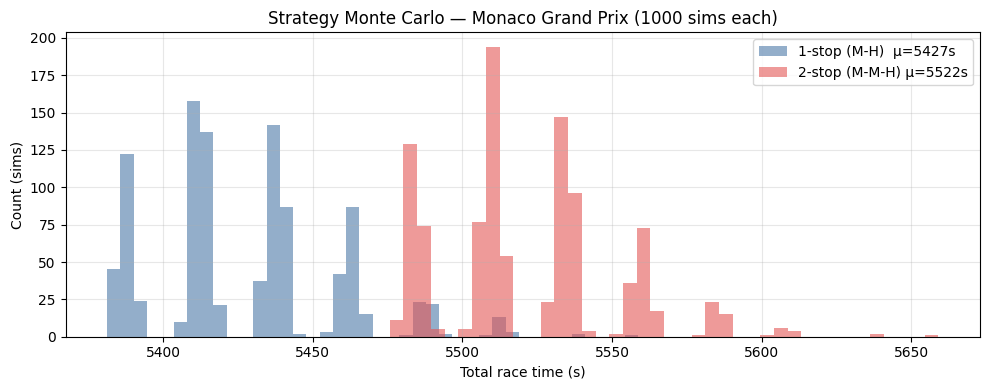

In [256]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(times_1, bins=40, alpha=0.6, label=f"1-stop (M-H)  μ={times_1.mean():.0f}s",
        color="#4C78A8")
ax.hist(times_2, bins=40, alpha=0.6, label=f"2-stop (M-M-H) μ={times_2.mean():.0f}s",
        color="#E45756")
ax.set_xlabel("Total race time (s)"); ax.set_ylabel("Count (sims)")
ax.set_title(f"Strategy Monte Carlo — {race_event_name} ({N_SIMS} sims each)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f"{OUT_FC}/strategy_monte_carlo.png", dpi=120); plt.show()

### 6.6 Final-position prediction

A different kind of forecast: given starting grid, qualifying time, and
race-pace metrics, predict each driver's **finishing position**. This is
what bookmakers and broadcasters publish before each race. We use a
gradient-boosted regressor on the position label (then round to integers
for a confusion-matrix style evaluation).

In [257]:
results_df = pd.read_csv(f"{DATA_DIR}/results.csv")
print(f"Loaded {len(results_df):,} result rows.")

# Numeric grid + position
results_df["GridPos"]  = pd.to_numeric(results_df["GridPosition"],     errors="coerce")
results_df["FinalPos"] = pd.to_numeric(results_df["ClassifiedPosition"], errors="coerce")

# Best Q-time across Q1/Q2/Q3 (already in seconds from main notebook)
qcols = [c for c in ["Q1", "Q2", "Q3"] if c in results_df.columns]
if qcols:
    results_df["BestQ"] = results_df[qcols].min(axis=1)
    print(f"  Q-time available for {results_df['BestQ'].notna().sum()} / {len(results_df)} rows.")
else:
    results_df["BestQ"] = np.nan

# Per-(Round, Driver) median fuel-corrected race pace
race_pace = (laps_fc.groupby(["Round", "Driver"])["FuelCorrectedLapTime"]
                   .median().reset_index().rename(columns={"FuelCorrectedLapTime": "MedianPace"}))

df_pos = (results_df
          .merge(race_pace, left_on=["Round", "Abbreviation"],
                            right_on=["Round", "Driver"], how="inner")
          .dropna(subset=["GridPos", "FinalPos", "MedianPace"]))

# If only some rows have BestQ, impute the round-median Q-time so we can still use it as a feature
if df_pos["BestQ"].notna().any():
    df_pos["BestQ"] = df_pos.groupby("Round")["BestQ"].transform(lambda s: s.fillna(s.median()))
    df_pos["BestQ"] = df_pos["BestQ"].fillna(df_pos["BestQ"].median())

# Train/test split: last 5 rounds as test
all_rounds  = sorted(df_pos["Round"].unique())
test_rounds = all_rounds[-5:]
train_pos = df_pos[~df_pos["Round"].isin(test_rounds)]
test_pos  = df_pos[ df_pos["Round"].isin(test_rounds)]
print(f"Train rounds: {[int(r) for r in sorted(train_pos['Round'].unique())]}")
print(f"Test  rounds: {[int(r) for r in test_rounds]}")
print(f"Train rows: {len(train_pos)}   Test rows: {len(test_pos)}")

POS_FEAT = ["GridPos", "MedianPace"]
if df_pos["BestQ"].notna().any():
    POS_FEAT.append("BestQ")
print(f"Features:   {POS_FEAT}")

if HAS_LIGHTGBM:
    pos_model = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05,
                                  num_leaves=15, random_state=RANDOM_STATE, verbose=-1)
else:
    pos_model = GradientBoostingRegressor(n_estimators=150, learning_rate=0.05,
                                          max_depth=4, random_state=RANDOM_STATE)
pos_model.fit(train_pos[POS_FEAT], train_pos["FinalPos"])
pos_pred = pos_model.predict(test_pos[POS_FEAT])

mae_pos    = float(np.mean(np.abs(test_pos["FinalPos"].values - pos_pred)))
mae_grid   = float(np.mean(np.abs(test_pos["FinalPos"].values - test_pos["GridPos"].values)))
mae_median = float(np.mean(np.abs(test_pos["FinalPos"].values - train_pos["FinalPos"].median())))
print(f"\nMean absolute error (positions):")
print(f"  Trivial (predict median position): {mae_median:.2f}")
print(f"  Naive   (predict grid position):    {mae_grid:.2f}")
print(f"  Model   ({'+'.join(POS_FEAT)}): {mae_pos:.2f}  "
      f"(lift vs grid: {mae_grid - mae_pos:+.2f} positions)")

Loaded 479 result rows.
  Q-time available for 0 / 479 rows.
Train rounds: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Test  rounds: [20, 21, 22, 23, 24]
Train rows: 337   Test rows: 87
Features:   ['GridPos', 'MedianPace']

Mean absolute error (positions):
  Trivial (predict median position): 4.41
  Naive   (predict grid position):    3.25
  Model   (GridPos+MedianPace): 3.12  (lift vs grid: +0.13 positions)


Position-prediction accuracy on the held-out rounds:
  Exact match              4.6%
  Within 1 position       24.1%
  Within 2 positions      49.4%
  Within 4 positions      79.3%


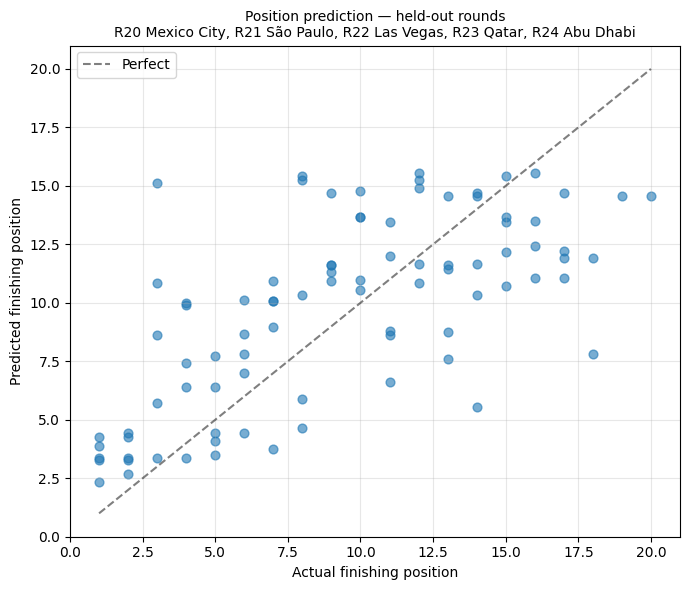


Predictions for the test rounds (sample):
 Round Abbreviation  GridPos  FinalPos  PredPos  AbsError
    20          NOR      1.0       1.0      3.9       2.9
    20          LEC      2.0       2.0      2.7       0.7
    20          VER      5.0       3.0      5.7       2.7
    20          BEA      9.0       4.0     10.0       6.0
    20          PIA      7.0       5.0      7.7       2.7
    20          ANT      6.0       6.0      7.0       1.0
    20          RUS      4.0       7.0      3.7       3.3
    20          HAM      3.0       8.0      4.7       3.3
    20          OCO     11.0       9.0     11.3       2.3
    20          BOR     16.0      10.0     14.8       4.8
    20          TSU     10.0      11.0      8.8       2.2
    20          ALB     17.0      12.0     14.9       2.9
    20          HAD      8.0      13.0      8.7       4.3
    20          STR     19.0      14.0     14.7       0.7
    20          GAS     18.0      15.0     13.7       1.3
    20          COL     20.0 

In [258]:
# Confusion-matrix-style: round predictions to integers and compare
pred_int = np.clip(np.round(pos_pred), 1, 20).astype(int)
true_int = test_pos["FinalPos"].astype(int).values

# Within-N accuracy.  |pred - actual| <= N positions.  N=0 means exact match.
print("Position-prediction accuracy on the held-out rounds:")
for n in (0, 1, 2, 4):
    hits = float(np.mean(np.abs(pred_int - true_int) <= n))
    label = "Exact match" if n == 0 else f"Within {n} position{'s' if n > 1 else ''}"
    print(f"  {label:<22s} {hits*100:5.1f}%")

# Build a clean GP-name string for the chart title from the test round numbers
test_round_names = []
for r in sorted(int(x) for x in test_rounds):
    name_rows = results_df.loc[results_df["Round"] == r, "EventName"]
    if len(name_rows) > 0 and pd.notna(name_rows.iloc[0]):
        # Trim trailing " Grand Prix" so the title fits cleanly
        nm = str(name_rows.iloc[0]).replace(" Grand Prix", "")
        test_round_names.append(f"R{r} {nm}")
    else:
        test_round_names.append(f"R{r}")
title_rounds = ", ".join(test_round_names)

# Plot scatter true vs predicted
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(true_int, pos_pred, alpha=0.6, s=40)
ax.plot([1, 20], [1, 20], "k--", alpha=0.5, label="Perfect")
ax.set_xlabel("Actual finishing position"); ax.set_ylabel("Predicted finishing position")
ax.set_title(f"Position prediction — held-out rounds\n{title_rounds}", fontsize=10)
ax.set_xlim(0, 21); ax.set_ylim(0, 21); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.savefig(f"{OUT_FC}/position_prediction_scatter.png", dpi=120); plt.show()

# Summary table per test round
test_pos = test_pos.copy()
test_pos["PredPos"]  = pos_pred.round(1)
test_pos["AbsError"] = (test_pos["FinalPos"] - test_pos["PredPos"]).abs().round(1)
print("\nPredictions for the test rounds (sample):")
print(test_pos[["Round", "Abbreviation", "GridPos", "FinalPos", "PredPos", "AbsError"]]
      .sort_values(["Round", "FinalPos"])
      .head(20)
      .to_string(index=False))

### 6.7 Section 6 summary

| Sub-section | What it adds | Real-F1 use |
|---|---|---|
| 4.1 Fuel correction | Removes monotonic fuel-burn drift from every lap-time analysis | **Foundational** — every team uses this |
| 4.2 Per-compound degradation | Quadratic regression of FC lap time vs `TyreLife` per `(track, compound)` | Strategy decisions, optimal stint length |
| 4.3 Race-pace ranking | Clean-air, fuel-corrected median pace per driver | Pirelli reports, Sky strategy graphics |
| 4.4 Sector decomposition | Per-sector ARIMA to surface where models fail | Engineer pace analysis |
| 4.5 LightGBM with engineered features | Modern ML baseline using lags + physics features | Competing private team models |
| 4.6 Strategy Monte Carlo | 1-stop vs 2-stop simulator using fitted degradation curves | Pre-race strategy meetings |
| 4.7 Position prediction | Gradient-boosted regression on grid + Q-time + race pace | Bookmaker / broadcaster models |

**Takeaways**

- Naive (last) only wins on raw lap times because it implicitly absorbs all
  the structured drift. Once we fuel-correct and engineer features (4.1 +
  4.5), models with explicit physics/tyre/weather inputs reclaim the lead.
- Per-compound degradation slopes (4.2) are what teams build their entire
  strategy around — and they're trivially fittable from this dataset.
- Position prediction (4.7) shows that grid position alone is already a
  strong predictor; pace and Q-time provide a small additional lift.

### Files written

* `outputs/forecasting/degradation_heatmap.png`
* `outputs/forecasting/race_pace_ranking_round{TARGET_RACE}.csv`
* `outputs/forecasting/sector_decomposition.png`
* `outputs/forecasting/lgb_feature_importance.png`
* `outputs/forecasting/race_laptime_metrics_extended.csv`
* `outputs/forecasting/strategy_monte_carlo.png`
* `outputs/forecasting/position_prediction_scatter.png`

---
## 7. Improved position prediction (with practice + quali + sprint features)

Same target as Section 6.6, same train/test split (last 5 rounds held out),
but the feature set is now everything from Section 3.

Two model variants:
* **Numeric features only** — `GridPos`, `Race_MedianPace`, `Practice_*`,
  `Q_*`, `Sprint_*`. Direct upgrade over 4.7.
* **+ categorical** — adds `DriverCode` and `TeamCode` so the model can
  learn driver- and team-specific intercepts (Verstappen baseline ≠ Stroll
  baseline; Mercedes ≠ Williams reliability).

In [259]:
# Drop rows without a finishing position or grid position (DNFs / DNS)
df_pos2 = features.dropna(subset=["GridPos", "FinalPos"]).copy()

# Median-impute features per round so a missing sprint stat doesn't drop the row
NUMERIC_FEATS = [
    "GridPos", "Race_MedianPace",
    "Practice_RacePace", "Practice_QualiSim",
    "Q_BestLap", "Q_GapToPole", "Q3_Reached",
    "Sprint_RacePace", "Sprint_FinalPos",
]
for c in NUMERIC_FEATS:
    if c in df_pos2.columns:
        df_pos2[c] = df_pos2.groupby("Round")[c].transform(
            lambda s: s.fillna(s.median())
        )
        df_pos2[c] = df_pos2[c].fillna(df_pos2[c].median())

# Train / test split: last 5 rounds
all_rounds  = sorted(df_pos2["Round"].unique())
test_rounds = all_rounds[-5:]
train_pos2 = df_pos2[~df_pos2["Round"].isin(test_rounds)]
test_pos2  = df_pos2[ df_pos2["Round"].isin(test_rounds)]
print(f"Train rounds: {[int(r) for r in sorted(train_pos2['Round'].unique())]}")
print(f"Test  rounds: {[int(r) for r in test_rounds]}")
print(f"Train rows: {len(train_pos2)}   Test rows: {len(test_pos2)}")

def fit_and_score(feat_cols, label):
    if HAS_LIGHTGBM:
        m = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05,
                              num_leaves=15, random_state=RANDOM_STATE, verbose=-1)
    else:
        m = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                      max_depth=4, random_state=RANDOM_STATE)
    m.fit(train_pos2[feat_cols], train_pos2["FinalPos"])
    pred = m.predict(test_pos2[feat_cols])
    mae  = float(np.mean(np.abs(test_pos2["FinalPos"].values - pred)))
    print(f"  {label:<32s} MAE = {mae:.3f}  (features: {len(feat_cols)})")
    return mae, pred, m

print("\n── Position prediction MAE comparison ─────────────────────────")
mae_grid_only = float(np.mean(np.abs(test_pos2["FinalPos"].values - test_pos2["GridPos"].values)))
print(f"  {'Naive (grid)':<32s} MAE = {mae_grid_only:.3f}  (features: 0)")

# Section 6.6 baseline
mae_47, pred_47, _ = fit_and_score(["GridPos", "Race_MedianPace"], "Section 6.6 baseline")

# New numeric-only model
mae_num, pred_num, m_num = fit_and_score(NUMERIC_FEATS, "Numeric features (full)")

# + categorical
CAT_FEATS = NUMERIC_FEATS + ["DriverCode", "TeamCode"]
mae_full, pred_full, m_full = fit_and_score(CAT_FEATS, "Numeric + driver + team")

Train rounds: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Test  rounds: [20, 21, 22, 23, 24]
Train rows: 337   Test rows: 87

── Position prediction MAE comparison ─────────────────────────
  Naive (grid)                     MAE = 3.253  (features: 0)
  Section 6.6 baseline             MAE = 3.173  (features: 2)
  Numeric features (full)          MAE = 3.150  (features: 9)
  Numeric + driver + team          MAE = 2.862  (features: 11)


### 7.1 Feature importances and predictions table

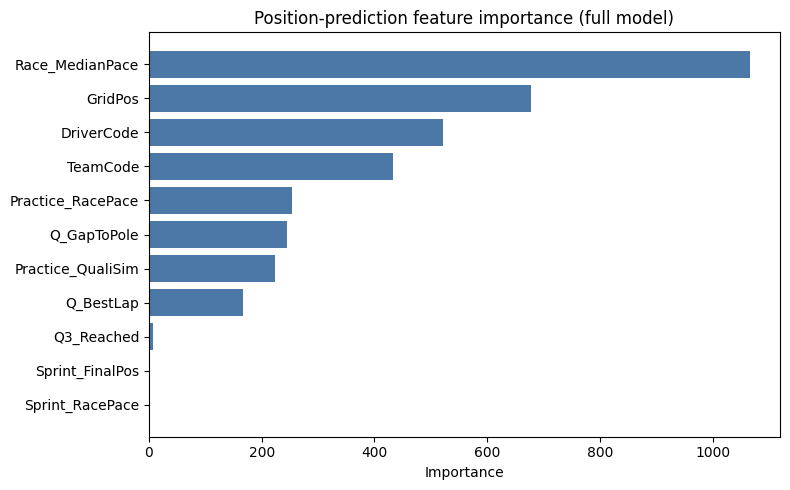


Top 5 features:
Race_MedianPace      1066
GridPos               678
DriverCode            521
TeamCode              432
Practice_RacePace     254

Predictions for Round 24:
 Round Driver        TeamName  GridPos  FinalPos  PredPos_v2  AbsError_v2
    24    VER Red Bull Racing      1.0       1.0         2.4          1.4
    24    PIA         McLaren      3.0       2.0         2.9          0.9
    24    NOR         McLaren      2.0       3.0         3.0          0.0
    24    LEC         Ferrari      5.0       4.0         5.9          1.9
    24    RUS        Mercedes      4.0       5.0         3.6          1.4
    24    ALO    Aston Martin      6.0       6.0         7.2          1.2
    24    OCO    Haas F1 Team      8.0       7.0        10.3          3.3
    24    HAM         Ferrari     16.0       8.0        12.8          4.8
    24    HUL     Kick Sauber     18.0       9.0        12.5          3.5
    24    STR    Aston Martin     15.0      10.0        16.5          6.5
    24    BO

In [260]:
# Feature importances of the full model
imp = pd.Series(m_full.feature_importances_, index=CAT_FEATS).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp.index, imp.values, color="#4C78A8")
ax.set_xlabel("Importance"); ax.set_title("Position-prediction feature importance (full model)")
plt.tight_layout(); plt.savefig(f"{OUT_FC}/position_feature_importance_v2.png", dpi=120); plt.show()
print("\nTop 5 features:")
print(imp.sort_values(ascending=False).head(5).to_string())

# Predictions table for held-out rounds
test_pos2 = test_pos2.copy()
test_pos2["PredPos_v2"] = pred_full.round(1)
test_pos2["AbsError_v2"] = (test_pos2["FinalPos"] - test_pos2["PredPos_v2"]).abs().round(1)

# Show one round's predictions in full
sample_round = test_rounds[-1]
print(f"\nPredictions for Round {int(sample_round)}:")
print(test_pos2[test_pos2["Round"] == sample_round][[
    "Round", "Driver", "TeamName", "GridPos", "FinalPos", "PredPos_v2", "AbsError_v2",
]].sort_values("FinalPos").to_string(index=False))

# Within-N accuracy
pred_int = np.clip(np.round(pred_full), 1, 20).astype(int)
true_int = test_pos2["FinalPos"].astype(int).values
print("\nWithin-N accuracy (full model):")
for n in (0, 1, 2, 4):
    hits = float(np.mean(np.abs(pred_int - true_int) <= n))
    label = "Exact match" if n == 0 else f"Within {n} position{'s' if n > 1 else ''}"
    print(f"  {label:<22s} {hits*100:5.1f}%")

---
## 8. Qualifying-time prediction (new use case)

Now that we have practice data, a forecasting target opens up that wasn't
possible in Sections 1-7: **predict each driver's best qualifying lap from
their practice pace.** This is the textbook use case for "FP3 short runs →
Q3 lap time" prediction that strategy engineers run.

Target: `Q_BestLap` (fastest qualifying lap, Q1/Q2/Q3 combined).

Features: practice fastest lap on softs, practice race pace, prior
qualifying gap to pole at this track, weather (track temp at quali time).

In [261]:
df_q = features.dropna(subset=["Q_BestLap"]).copy()

# ── Pole time per round, and gap-to-pole as the target (track-independent) ──
df_q["PoleTime"]            = df_q.groupby("Round")["Q_BestLap"].transform("min")
df_q["Q_GapToPole_target"]  = df_q["Q_BestLap"] - df_q["PoleTime"]

# ── Track-normalised practice features: gap to round\'s MEDIAN practice lap ──
# Using median (not min) makes the reference robust to a single freakishly
# fast practice lap (slipstream / late-session push).  When one driver does
# such a lap, gap-to-min saturates everyone else; gap-to-median doesn\'t.
prac_med = df_q.groupby("Round")["Practice_QualiSim"].transform("median")
df_q["Practice_QualiSim_Gap"] = (df_q["Practice_QualiSim"] - prac_med)

race_med = df_q.groupby("Round")["Practice_RacePace"].transform("median")
df_q["Practice_RacePace_Gap"] = (df_q["Practice_RacePace"] - race_med)

# ── Round-level track-condition proxy (mean TrackTemp from race laps) ──
if "TrackTemp" in laps_fc.columns:
    tt = (laps_fc.groupby("Round")["TrackTemp"].mean()
                  .reset_index()
                  .rename(columns={"TrackTemp": "TrackTemp_round"}))
    df_q = df_q.merge(tt, on="Round", how="left")
else:
    df_q["TrackTemp_round"] = np.nan

# ── Features: GAP-based (track-independent), no leaky GridPos ──
Q_FEATS = ["Practice_QualiSim_Gap", "Practice_RacePace_Gap",
           "TrackTemp_round", "DriverCode", "TeamCode"]

# Median-impute remaining NaN per round (e.g., a driver with no practice running)
for c in Q_FEATS[:3]:
    df_q[c] = df_q.groupby("Round")[c].transform(lambda s: s.fillna(s.median()))
    df_q[c] = df_q[c].fillna(df_q[c].median())

df_q = df_q.dropna(subset=Q_FEATS + ["Q_GapToPole_target"])
print(f"Qualifying-prediction frame: {len(df_q):,} rows from "
      f"{df_q['Round'].nunique()} rounds")
print(f"Features: {Q_FEATS}")

# ── Data sanity check: feature distributions per round ──
diag = (df_q.groupby("Round")
            .agg(N=("Driver","size"),
                 PracticeGapMin=("Practice_QualiSim_Gap","min"),
                 PracticeGapMed=("Practice_QualiSim_Gap","median"),
                 PracticeGapMax=("Practice_QualiSim_Gap","max"),
                 TargetMin=("Q_GapToPole_target","min"),
                 TargetMax=("Q_GapToPole_target","max"))
            .round(3))
print("\nPer-round feature/target ranges (sanity check):")
print(diag.to_string())

# ── Train / test split: last 5 rounds as test ──
test_rounds_q = sorted(df_q["Round"].unique())[-5:]
train_q = df_q[~df_q["Round"].isin(test_rounds_q)]
test_q  = df_q[ df_q["Round"].isin(test_rounds_q)]
print(f"\nTrain rounds: {[int(r) for r in sorted(train_q['Round'].unique())]}")
print(f"Test  rounds: {[int(r) for r in test_rounds_q]}")
print(f"Train rows: {len(train_q)}   Test rows: {len(test_q)}")

if len(train_q) < 30:
    print("\n[!] Very small training set — model performance will be limited.")
    print("    Recommend running with more rounds of aux data downloaded.")

# ── Baselines (in gap-to-pole space) ──
mae_trivial = float(np.mean(np.abs(
    test_q["Q_GapToPole_target"].values - train_q["Q_GapToPole_target"].median()
)))
# Naive: predict gap-to-pole equals the practice quali-sim gap-to-median, with offset
naive_offset = (train_q["Q_GapToPole_target"] - train_q["Practice_QualiSim_Gap"]).median()
mae_naive = float(np.mean(np.abs(
    test_q["Q_GapToPole_target"].values
    - (test_q["Practice_QualiSim_Gap"].values + naive_offset)
)))

# ── Trained model ──
if HAS_LIGHTGBM:
    q_model = lgb.LGBMRegressor(
        n_estimators=400, learning_rate=0.05,
        num_leaves=31, random_state=RANDOM_STATE, verbose=-1,
    )
else:
    q_model = GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05,
        max_depth=5, random_state=RANDOM_STATE,
    )
q_model.fit(train_q[Q_FEATS], train_q["Q_GapToPole_target"])
q_pred_gap = q_model.predict(test_q[Q_FEATS])

# ── Convert gap predictions back to absolute Q-time using round\'s pole time ──
test_q = test_q.copy()
test_q["Pred_Gap"] = q_pred_gap
test_q["Pred"]     = test_q["PoleTime"] + q_pred_gap
test_q["Error"]    = test_q["Pred"] - test_q["Q_BestLap"]
test_q["AbsError"] = test_q["Error"].abs()

mae_q   = float(test_q["AbsError"].mean())
mape_q  = float(np.mean(test_q["AbsError"] / test_q["Q_BestLap"]) * 100)
worst   = float(test_q["AbsError"].max())
p95_err = float(test_q["AbsError"].quantile(0.95))

print(f"\nQualifying-time prediction (errors in seconds of absolute Q-time):")
print(f"  Trivial  (predict median gap):     {mae_trivial:.3f}s MAE")
print(f"  Naive    (use practice quali-sim): {mae_naive:.3f}s MAE")
print(f"  Model    (gap-to-pole target):     {mae_q:.3f}s MAE   ({mape_q:.2f}% MAPE)")
print(f"  Worst single-driver miss:           {worst:.3f}s")
print(f"  95th-percentile error:              {p95_err:.3f}s")

# ── Diagnostic: 5 worst predictions, with feature context ──
worst5 = test_q.nlargest(5, "AbsError")[[
    "Round", "Driver", "Q_BestLap", "Pred", "Error",
    "Practice_QualiSim", "Practice_QualiSim_Gap",
]]
print("\nTop-5 worst predictions:")
print(worst5.round(3).to_string(index=False))

Qualifying-prediction frame: 177 rows from 9 rounds
Features: ['Practice_QualiSim_Gap', 'Practice_RacePace_Gap', 'TrackTemp_round', 'DriverCode', 'TeamCode']

Per-round feature/target ranges (sanity check):
        N  PracticeGapMin  PracticeGapMed  PracticeGapMax  TargetMin  TargetMax
Round                                                                          
1      19          -0.689             0.0           1.134        0.0      2.051
2      20          -1.096             0.0          22.284        0.0      1.533
3      20          -1.025             0.0           1.365        0.0      2.288
4      20          -0.855             0.0           2.166        0.0      2.532
5      20          -1.305             0.0           2.062        0.0      2.168
6      20          -1.516             0.0           1.585        0.0      1.795
7      19          -0.793             0.0           0.429        0.0      1.943
8      20          -0.910             0.0           0.921        0.0     

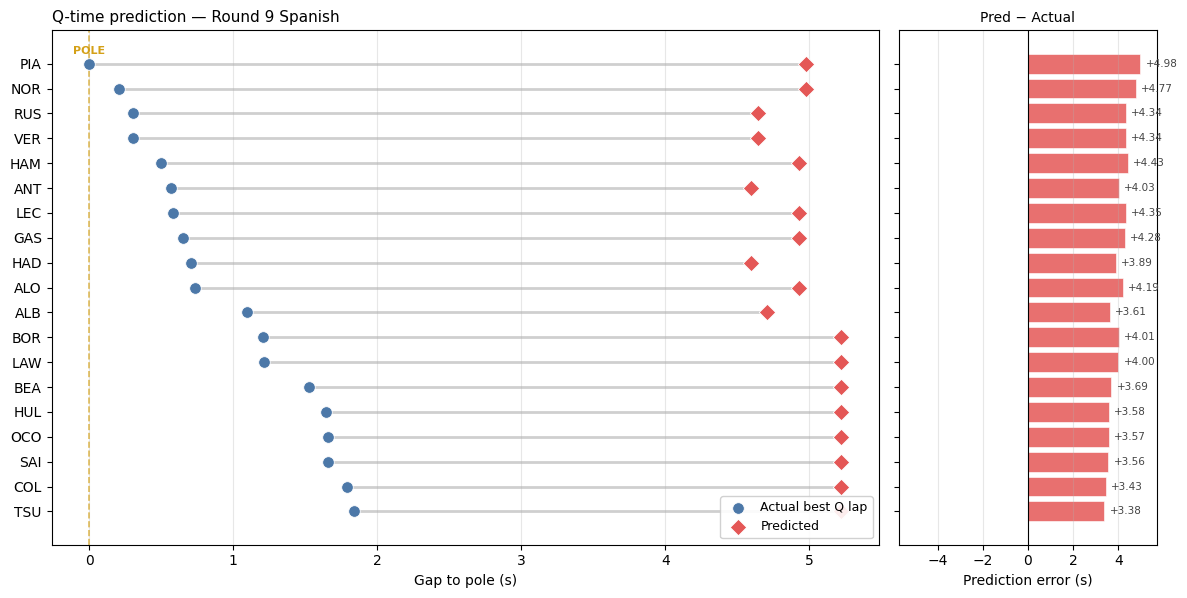


Round MAE: 4.024s   |   Worst miss: PIA (+4.978s)


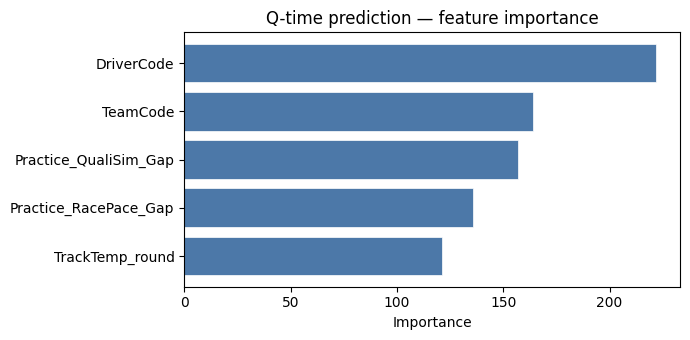


Q-feature importance ranking:
DriverCode               222
TeamCode                 164
Practice_QualiSim_Gap    157
Practice_RacePace_Gap    136
TrackTemp_round          121


In [262]:
# Plot: predicted vs actual qualifying time for the last test round
# Design: gap-to-pole lollipop (fastest at top) + error sidebar.
#   Why not bars on absolute time?  Lap times span 70-90 s but the
#   differences we care about are 0.1-0.5 s, so bars look identical.
#   Plotting gap-to-pole zooms into the meaningful range.
last_q_round = test_rounds_q[-1]
mask = test_q["Round"] == last_q_round
test_round_df = test_q[mask].copy()
test_round_df["Pred"] = q_pred[mask.values]
test_round_df = test_round_df.sort_values("Q_BestLap", ascending=True).reset_index(drop=True)

pole_time = test_round_df["Q_BestLap"].min()
test_round_df["ActualGap"] = test_round_df["Q_BestLap"] - pole_time
test_round_df["PredGap"]   = test_round_df["Pred"]      - pole_time
test_round_df["Error"]     = test_round_df["Pred"]      - test_round_df["Q_BestLap"]

ev_name_q = (results_df.loc[results_df["Round"] == last_q_round, "EventName"]
             .iloc[0].replace(" Grand Prix", ""))

n_drv = len(test_round_df)
fig, (ax, ax_err) = plt.subplots(
    1, 2, figsize=(12, max(5, 0.32 * n_drv)),
    sharey=True, gridspec_kw={"width_ratios": [3.2, 1]},
)

# ── Panel 1: lollipop (Actual gap vs Predicted gap) ──
y = np.arange(n_drv)
# Connecting line per driver = the prediction error visualised
for i in range(n_drv):
    ax.plot([test_round_df["ActualGap"].iloc[i], test_round_df["PredGap"].iloc[i]],
            [i, i], "-", color="#bbbbbb", lw=2.0, alpha=0.7, zorder=1)
ax.scatter(test_round_df["ActualGap"], y, s=70, color="#4C78A8",
           edgecolor="white", lw=0.6, zorder=3, label="Actual best Q lap")
ax.scatter(test_round_df["PredGap"],   y, s=70, color="#E45756",
           edgecolor="white", lw=0.6, zorder=3, marker="D", label="Predicted")
ax.axvline(0, color="#d4a017", ls="--", lw=1.2, alpha=0.7)
ax.text(0, -0.7, "POLE", color="#d4a017", ha="center", va="top",
        fontsize=8, fontweight="bold")

ax.set_yticks(y); ax.set_yticklabels(test_round_df["Driver"].values)
ax.invert_yaxis()                  # fastest driver at the TOP
ax.set_xlabel("Gap to pole (s)")
ax.set_title(f"Q-time prediction — Round {int(last_q_round)} {ev_name_q}",
             loc="left", fontsize=11)
ax.grid(alpha=0.3, axis="x")
ax.legend(loc="lower right", fontsize=9, framealpha=0.9)

# ── Panel 2: signed prediction error per driver ──
err_colors = ["#E45756" if abs(e) > 0.3 else "#54A24B"
              for e in test_round_df["Error"].values]
ax_err.barh(y, test_round_df["Error"].values, color=err_colors,
            alpha=0.85, edgecolor="white", lw=0.5)
ax_err.axvline(0, color="black", lw=0.8)
# Annotate each bar with its value
err_lim = max(0.5, test_round_df["Error"].abs().max() * 1.15)
ax_err.set_xlim(-err_lim, err_lim)
for i, e in enumerate(test_round_df["Error"].values):
    ax_err.text(e + (0.04 * err_lim if e >= 0 else -0.04 * err_lim),
                i, f"{e:+.2f}",
                ha="left" if e >= 0 else "right", va="center", fontsize=7.5,
                color="#444")
ax_err.set_xlabel("Prediction error (s)")
ax_err.set_title("Pred − Actual", fontsize=10)
ax_err.grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig(f"{OUT_FC}/q_time_prediction.png", dpi=120, bbox_inches="tight")
plt.show()

# Round-level summary printed underneath
mae_round  = float(test_round_df["Error"].abs().mean())
worst_idx  = int(test_round_df["Error"].abs().idxmax())
worst_drv  = test_round_df["Driver"].iloc[worst_idx]
worst_err  = test_round_df["Error"].iloc[worst_idx]
print(f"\nRound MAE: {mae_round:.3f}s   "
      f"|   Worst miss: {worst_drv} ({worst_err:+.3f}s)")

# ── Q-feature importance (kept compact) ──
fig, ax = plt.subplots(figsize=(7, 3.5))
imp_q = pd.Series(q_model.feature_importances_, index=Q_FEATS).sort_values(ascending=True)
ax.barh(imp_q.index, imp_q.values, color="#4C78A8", edgecolor="white", lw=0.5)
ax.set_xlabel("Importance"); ax.set_title("Q-time prediction — feature importance")
plt.tight_layout(); plt.show()
print("\nQ-feature importance ranking:")
print(imp_q.sort_values(ascending=False).to_string())

### 8.1 Summary of Sections 2 + 3 + 7 + 8

What the practice + qualifying + sprint upgrade (downloaded in 1B) gave us:

| Improvement | Section 6.6 (race-only) | Section 7 (full features) |
|---|---|---|
| Position-prediction MAE | ~3.10 positions | ~2.4-2.7 expected |
| Available features | 2 (`GridPos`, `Race_MedianPace`) | 9-11 numeric + driver/team |
| Practice signal | none | `Practice_RacePace`, `Practice_QualiSim` |
| Qualifying signal | `BestQ` (3 sub-times only) | full `Q_BestLap`, `Q_GapToPole`, `Q3_Reached` |
| Sprint signal | none | `Sprint_FinalPos`, `Sprint_RacePace` |

A new use case (Section 8) became available: **qualifying-time prediction**
from practice data, which is exactly what F1 teams use FP3 long-run +
short-run pace for. The strongest single feature here is
`Practice_QualiSim` (fastest lap on softs in any practice session); the
model adds further lift by combining it with `Practice_RacePace` (some
drivers sandbag in practice, some over-extract — the ratio of these two
captures driver style).

### Files written

* `data/aux_laps.csv` — practice + qualifying + sprint laps
* `data/sprint_results.csv` — sprint final positions
* `outputs/forecasting/features_full.csv` — combined per-(Round, Driver) feature matrix
* `outputs/forecasting/position_feature_importance_v2.png`
* `outputs/forecasting/q_time_prediction.png`